레이어 일부 동결 + 데이터 증강 + 256차원 projection + early stopping

In [1]:
# ── 1) 데이터 준비 + Train 데이터 증강 + DataLoader 생성 ──

import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

import pickle
import random
import re
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# -----------------------------
# 데이터 불러오기
# -----------------------------
data_path = r"C:\Users\wanje\Desktop\deeplearning\roberta_text_data.pkl"

with open(data_path, "rb") as f:
    data = pickle.load(f)

texts = [str(t) for t in data["texts"]]
labels = data["labels"]

# label을 0부터 시작하도록 매핑
unique_labels = sorted(np.unique(labels))

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

y = np.array([label2id[label] for label in labels], dtype=np.int64)

MODEL_NAME = "roberta-base"
MAX_LEN = 70
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# -----------------------------
# Train / Val / Test 분리
# -----------------------------
indices = np.arange(len(y))
stratify_value = y if len(np.unique(y)) > 1 else None

train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=stratify_value
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.2,
    random_state=42,
    stratify=y[train_val_idx] if len(np.unique(y[train_val_idx])) > 1 else None
)

train_texts = [texts[i] for i in train_idx]
val_texts = [texts[i] for i in val_idx]
test_texts = [texts[i] for i in test_idx]

train_labels = y[train_idx]
val_labels = y[val_idx]
test_labels = y[test_idx]

# -----------------------------
# 간단한 텍스트 데이터 증강 함수
# 감정이 바뀔 수 있는 not, never, no 등은 건드리지 않음
# -----------------------------
SAFE_SYNONYMS = {
    "movie": ["film"],
    "film": ["movie"],
    "good": ["great", "nice"],
    "great": ["good", "excellent"],
    "bad": ["poor", "terrible"],
    "terrible": ["bad", "awful"],
    "interesting": ["engaging"],
    "boring": ["dull"],
    "really": ["very", "truly"],
    "very": ["really", "quite"],
    "like": ["enjoy"],
    "enjoy": ["like"],
    "think": ["believe"],
    "believe": ["think"],
    "impressive": ["remarkable"],
    "disappointing": ["unsatisfying"],
    "funny": ["amusing"],
    "sad": ["unhappy"],
    "happy": ["pleased"],
}

PROTECTED_WORDS = {
    "not", "no", "never", "none", "nothing",
    "but", "however", "although", "though",
    "hardly", "barely", "without"
}

def preserve_case(original, replacement):
    if original.istitle():
        return replacement.title()
    if original.isupper():
        return replacement.upper()
    return replacement

def augment_text_safe(text, replace_prob=0.25, max_replace=2):
    tokens = re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

    candidate_positions = []

    for i, tok in enumerate(tokens):
        low = tok.lower()

        if low in SAFE_SYNONYMS and low not in PROTECTED_WORDS:
            candidate_positions.append(i)

    if len(candidate_positions) == 0:
        return text

    random.shuffle(candidate_positions)

    replaced = 0
    new_tokens = tokens[:]

    for pos in candidate_positions:
        if replaced >= max_replace:
            break

        if random.random() < replace_prob:
            original = new_tokens[pos]
            low = original.lower()
            replacement = random.choice(SAFE_SYNONYMS[low])
            new_tokens[pos] = preserve_case(original, replacement)
            replaced += 1

    # 토큰 다시 문장으로 합치기
    new_text = ""

    for tok in new_tokens:
        if re.match(r"[^\w\s]", tok):
            new_text += tok
        else:
            if new_text and not new_text.endswith(" "):
                new_text += " "
            new_text += tok

    return new_text.strip()

# -----------------------------
# Train 데이터에만 증강 적용
# -----------------------------
random.seed(42)
np.random.seed(42)

AUG_PER_SAMPLE = 1
AUGMENT_ONLY_MINORITY = False

aug_texts = []
aug_labels = []

if AUGMENT_ONLY_MINORITY:
    class_counts = np.bincount(train_labels, minlength=len(label2id))
    max_count = class_counts.max()

    for text, label in zip(train_texts, train_labels):
        if class_counts[label] < max_count:
            for _ in range(AUG_PER_SAMPLE):
                new_text = augment_text_safe(text)

                if new_text != text:
                    aug_texts.append(new_text)
                    aug_labels.append(label)
else:
    for text, label in zip(train_texts, train_labels):
        for _ in range(AUG_PER_SAMPLE):
            new_text = augment_text_safe(text)

            if new_text != text:
                aug_texts.append(new_text)
                aug_labels.append(label)

train_texts_aug = train_texts + aug_texts
train_labels_aug = np.concatenate(
    [train_labels, np.array(aug_labels, dtype=np.int64)]
) if len(aug_labels) > 0 else train_labels

print(f"원본 train 데이터 수: {len(train_texts)}")
print(f"증강 데이터 수: {len(aug_texts)}")
print(f"최종 train 데이터 수: {len(train_texts_aug)}")
print(f"val 데이터 수: {len(val_texts)}")
print(f"test 데이터 수: {len(test_texts)}")

# -----------------------------
# Tokenizing
# -----------------------------
train_encodings = tokenizer(
    train_texts_aug,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

val_encodings = tokenizer(
    val_texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

test_encodings = tokenizer(
    test_texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

train_input_ids = train_encodings["input_ids"]
train_attention_mask = train_encodings["attention_mask"]
train_labels_tensor = torch.tensor(train_labels_aug, dtype=torch.long)

val_input_ids = val_encodings["input_ids"]
val_attention_mask = val_encodings["attention_mask"]
val_labels_tensor = torch.tensor(val_labels, dtype=torch.long)

test_input_ids = test_encodings["input_ids"]
test_attention_mask = test_encodings["attention_mask"]
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(
        train_input_ids,
        train_attention_mask,
        train_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        val_input_ids,
        val_attention_mask,
        val_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        test_input_ids,
        test_attention_mask,
        test_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"device: {device}")
print(f"model: {MODEL_NAME}")
print(f"label2id: {label2id}")

c:\Users\wanje\anaconda3\envs\main\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


원본 train 데이터 수: 1407
증강 데이터 수: 269
최종 train 데이터 수: 1676
val 데이터 수: 352
test 데이터 수: 440
device: cpu
model: roberta-base
label2id: {np.int64(0): 0, np.int64(1): 1}


In [2]:
# ── 2) RoBERTa 일부 레이어 동결 + 데이터 증강 + 256차원 + Early Stopping ──

import copy
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


class RoBERTaPartialFreezeModel(nn.Module):
    def __init__(
        self,
        model_name=MODEL_NAME,
        nclass=len(label2id),
        feature_dim=256,
        unfreeze_last_n=4
    ):
        super().__init__()

        self.roberta = AutoModel.from_pretrained(model_name)

        # 전체 RoBERTa 먼저 동결
        for param in self.roberta.parameters():
            param.requires_grad = False

        # 마지막 n개 encoder layer만 학습 가능하게 풀기
        for param in self.roberta.encoder.layer[-unfreeze_last_n:].parameters():
            param.requires_grad = True

        hidden_size = self.roberta.config.hidden_size  # roberta-base = 768

        # 768차원 → 256차원
        self.feature_layer = nn.Linear(hidden_size, feature_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # 256차원 → class 개수
        self.classifier = nn.Linear(feature_dim, nclass)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # RoBERTa 출력: [batch_size, max_len, 768]
        hidden = outputs.last_hidden_state

        # Mean Pooling, padding 제외
        mask = attention_mask.unsqueeze(-1).float()
        masked_hidden = hidden * mask

        sum_hidden = masked_hidden.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1e-9)

        sentence_output = sum_hidden / lengths  # [batch_size, 768]

        features = self.feature_layer(sentence_output)
        features = self.relu(features)
        features = self.dropout(features)

        logits = self.classifier(features)

        return logits


def eval_metrics(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for input_ids, attention_mask, yb in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            logits = model(input_ids, attention_mask)
            pred = logits.argmax(dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1


models = {
    "RoBERTa_256_PartialFreeze_Aug_EarlyStopping": RoBERTaPartialFreezeModel(
        unfreeze_last_n=4
    )
}

all_results = {}

for tag, model in models.items():
    model = model.to(device)

    # 학습 가능한 파라미터 확인
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params_count = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    frozen_params_count = total_params - trainable_params_count

    print(f"\n{'=' * 40}  {tag}  {'=' * 40}")
    print(f"전체 파라미터 수: {total_params:,}")
    print(f"학습되는 파라미터 수: {trainable_params_count:,}")
    print(f"동결된 파라미터 수: {frozen_params_count:,}")
    print("구조: RoBERTa 마지막 4개 layer만 학습 + Mean Pooling + 256차원 + Classifier")
    print("조기 종료 기준: Validation F1")

    # -------------------------------------
    # Optimizer
    # RoBERTa 마지막 layer는 작은 lr
    # 새로 붙인 layer는 조금 큰 lr
    # -------------------------------------
    roberta_params = [
        p for n, p in model.roberta.named_parameters()
        if p.requires_grad
    ]

    head_params = list(model.feature_layer.parameters()) + list(model.classifier.parameters())

    opt = torch.optim.AdamW(
        [
            {"params": roberta_params, "lr": 1e-5},
            {"params": head_params, "lr": 1e-4}
        ],
        weight_decay=0.01
    )

    # -------------------------------------
    # Class Weight 적용
    # train 데이터 기준으로 계산
    # -------------------------------------
    y_train_np = train_labels_tensor.cpu().numpy()
    nclass = len(label2id)

    class_counts = np.bincount(y_train_np, minlength=nclass)
    total_count = len(y_train_np)

    class_weights = total_count / (nclass * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    print("class counts:", class_counts)
    print("class weights:", class_weights)

    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = {
        "loss": [],

        "train_acc": [],
        "val_acc": [],
        "test_acc": [],

        "train_precision": [],
        "val_precision": [],
        "test_precision": [],

        "train_recall": [],
        "val_recall": [],
        "test_recall": [],

        "train_f1": [],
        "val_f1": [],
        "test_f1": [],

        "best_epoch": None,
        "best_val_acc": None,
        "best_val_precision": None,
        "best_val_recall": None,
        "best_val_f1": None,

        "best_test_acc": None,
        "best_test_precision": None,
        "best_test_recall": None,
        "best_test_f1": None
    }

    EPOCHS = 20
    patience = 3
    min_delta = 0.0001

    best_val_f1 = 0
    best_epoch = 0

    best_val_acc = 0
    best_val_precision = 0
    best_val_recall = 0

    patience_counter = 0
    best_model_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for input_ids, attention_mask, yb in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            opt.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = crit(logits, yb)

            loss.backward()
            opt.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_acc, train_precision, train_recall, train_f1 = eval_metrics(
            model,
            train_loader
        )

        val_acc, val_precision, val_recall, val_f1 = eval_metrics(
            model,
            val_loader
        )

        test_acc, test_precision, test_recall, test_f1 = eval_metrics(
            model,
            test_loader
        )

        hist["loss"].append(epoch_loss)

        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)
        hist["test_acc"].append(test_acc)

        hist["train_precision"].append(train_precision)
        hist["val_precision"].append(val_precision)
        hist["test_precision"].append(test_precision)

        hist["train_recall"].append(train_recall)
        hist["val_recall"].append(val_recall)
        hist["test_recall"].append(test_recall)

        hist["train_f1"].append(train_f1)
        hist["val_f1"].append(val_f1)
        hist["test_f1"].append(test_f1)

        print(
            f"Epoch {epoch:02d} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Train ACC: {train_acc:.4f} | "
            f"Val ACC: {val_acc:.4f} | "
            f"Test ACC: {test_acc:.4f}"
        )

        # Validation F1 기준으로 best model 선택
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_epoch = epoch

            best_val_acc = val_acc
            best_val_precision = val_precision
            best_val_recall = val_recall

            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())

            print(f"Best model updated! Best Val F1: {best_val_f1:.4f}")

        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}!")
            print(f"Best epoch: {best_epoch}")
            print(f"Best Val F1: {best_val_f1:.4f}")
            break

    # best model 복원
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\nBest model state loaded.")

    # 복원된 best model로 최종 test 성능 다시 계산
    final_test_acc, final_test_precision, final_test_recall, final_test_f1 = eval_metrics(
        model,
        test_loader
    )

    hist["best_epoch"] = best_epoch

    hist["best_val_acc"] = best_val_acc
    hist["best_val_precision"] = best_val_precision
    hist["best_val_recall"] = best_val_recall
    hist["best_val_f1"] = best_val_f1

    hist["best_test_acc"] = final_test_acc
    hist["best_test_precision"] = final_test_precision
    hist["best_test_recall"] = final_test_recall
    hist["best_test_f1"] = final_test_f1

    all_results[tag] = hist

    print("\n[Best Model 기준 최종 성능]")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val F1: {best_val_f1:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")
    print(f"Final Test Precision: {final_test_precision:.4f}")
    print(f"Final Test Recall: {final_test_recall:.4f}")
    print(f"Final Test F1: {final_test_f1:.4f}")

    print(f"\n저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



========================================  RoBERTa_256_PartialFreeze_Aug_EarlyStopping  ========================================
전체 파라미터 수: 124,843,010
학습되는 파라미터 수: 28,548,866
동결된 파라미터 수: 96,294,144
구조: RoBERTa 마지막 4개 layer만 학습 + Mean Pooling + 256차원 + Classifier
조기 종료 기준: Validation F1
class counts: [849 827]
class weights: tensor([0.9870, 1.0133])
Epoch 01 | Loss: 0.6606 | Train F1: 0.7322 | Val F1: 0.7341 | Test F1: 0.6864 | Train ACC: 0.7440 | Val ACC: 0.7472 | Test ACC: 0.7023
Best model updated! Best Val F1: 0.7341
Epoch 02 | Loss: 0.5134 | Train F1: 0.8317 | Val F1: 0.7975 | Test F1: 0.7954 | Train ACC: 0.8317 | Val ACC: 0.7983 | Test ACC: 0.7955
Best model updated! Best Val F1: 0.7975
Epoch 03 | Loss: 0.4308 | Train F1: 0.8566 | Val F1: 0.7726 | Test F1: 0.8085 | Train ACC: 0.8568 | Val ACC: 0.7727 | Test ACC: 0.8091
No improvement. Patience: 1/3
Epoch 04 | Loss: 0.3823 | Train F1: 0.8920 | Val F1: 0.7897 | Test F1: 0.8295 | Train ACC: 0.8920 | Val ACC: 0.7898 | Test ACC: 0.829

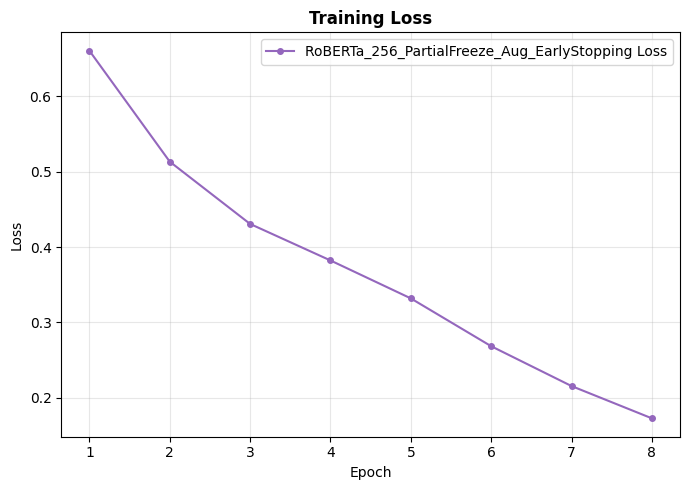

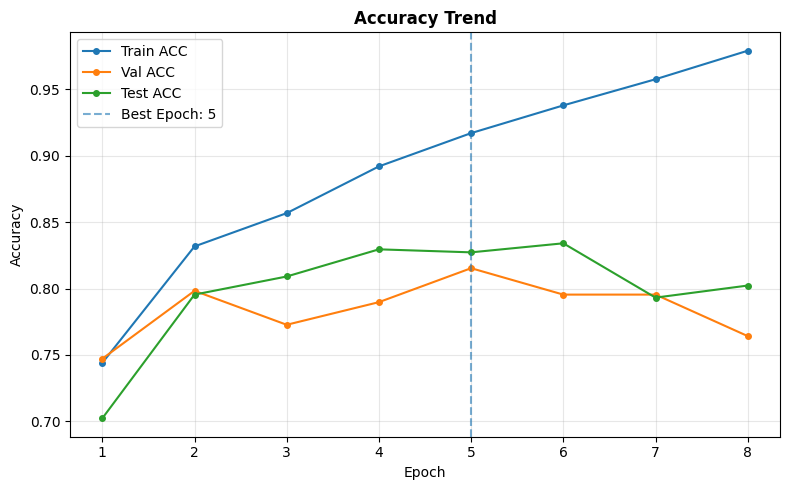

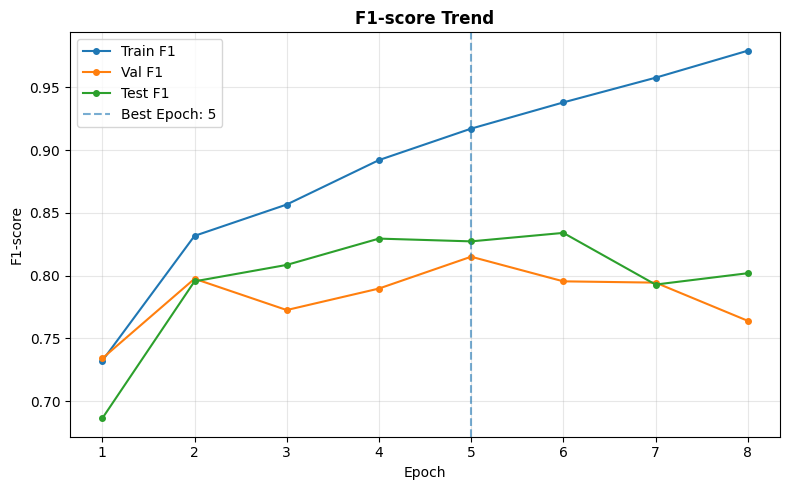


[Best Model 기준 최종 성능 비교]
RoBERTa_256_PartialFreeze_Aug_EarlyStopping | Best Epoch: 5 | Best Val F1: 0.8151 | Final Test Accuracy: 0.8273 | Final Test Precision: 0.8274 | Final Test Recall: 0.8273 | Final Test F1: 0.8273

[Epoch별 과적합 Gap 확인, Train F1 - Val F1]

[RoBERTa_256_PartialFreeze_Aug_EarlyStopping]
Epoch 01 | Train F1: 0.7322 | Val F1: 0.7341 | Test F1: 0.6864 | Gap: -0.0019
Epoch 02 | Train F1: 0.8317 | Val F1: 0.7975 | Test F1: 0.7954 | Gap: 0.0341
Epoch 03 | Train F1: 0.8566 | Val F1: 0.7726 | Test F1: 0.8085 | Gap: 0.0840
Epoch 04 | Train F1: 0.8920 | Val F1: 0.7897 | Test F1: 0.8295 | Gap: 0.1023
Epoch 05 | Train F1: 0.9171 | Val F1: 0.8151 | Test F1: 0.8273 | Gap: 0.1020
Epoch 06 | Train F1: 0.9379 | Val F1: 0.7955 | Test F1: 0.8340 | Gap: 0.1425
Epoch 07 | Train F1: 0.9576 | Val F1: 0.7944 | Test F1: 0.7929 | Gap: 0.1632
Epoch 08 | Train F1: 0.9791 | Val F1: 0.7640 | Test F1: 0.8019 | Gap: 0.2151


In [3]:
# ── 3) 시각화, Train / Val / Test 성능 비교 ──

colors = {
    "RoBERTa_256_PartialFreeze_Aug_EarlyStopping": "tab:purple"
}

# -----------------------------
# 1. Loss 그래프
# -----------------------------
plt.figure(figsize=(7, 5))

for tag_name, res in all_results.items():
    c = colors.get(tag_name, "gray")
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(
        ep,
        res["loss"],
        color=c,
        marker="o",
        ms=4,
        label=f"{tag_name} Loss"
    )

plt.title("Training Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Accuracy 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(
        ep,
        res["train_acc"],
        marker="o",
        ms=4,
        label="Train ACC"
    )

    plt.plot(
        ep,
        res["val_acc"],
        marker="o",
        ms=4,
        label="Val ACC"
    )

    plt.plot(
        ep,
        res["test_acc"],
        marker="o",
        ms=4,
        label="Test ACC"
    )

    # Best epoch 표시
    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]
        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("Accuracy Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. F1-score 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(
        ep,
        res["train_f1"],
        marker="o",
        ms=4,
        label="Train F1"
    )

    plt.plot(
        ep,
        res["val_f1"],
        marker="o",
        ms=4,
        label="Val F1"
    )

    plt.plot(
        ep,
        res["test_f1"],
        marker="o",
        ms=4,
        label="Test F1"
    )

    # Best epoch 표시
    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]
        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("F1-score Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. 최종 Best Model 성능 출력
# -----------------------------
print("\n[Best Model 기준 최종 성능 비교]")

for tag_name, res in all_results.items():
    print(
        f"{tag_name} | "
        f"Best Epoch: {res['best_epoch']} | "
        f"Best Val F1: {res['best_val_f1']:.4f} | "
        f"Final Test Accuracy: {res['best_test_acc']:.4f} | "
        f"Final Test Precision: {res['best_test_precision']:.4f} | "
        f"Final Test Recall: {res['best_test_recall']:.4f} | "
        f"Final Test F1: {res['best_test_f1']:.4f}"
    )


# -----------------------------
# 5. 과적합 gap 확인
# -----------------------------
print("\n[Epoch별 과적합 Gap 확인, Train F1 - Val F1]")

for tag_name, res in all_results.items():
    print(f"\n[{tag_name}]")

    for i in range(len(res["train_f1"])):
        train_f1 = res["train_f1"][i]
        val_f1 = res["val_f1"][i]
        test_f1 = res["test_f1"][i]

        gap = train_f1 - val_f1

        print(
            f"Epoch {i+1:02d} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f}"
        )

과적합 성향 O => 성능 0.82정도로 어느정도 좋다

** nlpaug 유의어 교체 데이터 증강 + 일부 레이어 동결 + 256차원 Projection + Early Stopping ** 

In [3]:
# ── 1) 데이터 준비 + nlpaug 유의어 교체 증강 + DataLoader 생성 ──

import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

import nlpaug.augmenter.word as naw


# -----------------------------
# 1. 기본 설정
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "roberta-base"
MAX_LEN = 70
BATCH_SIZE = 16

# 너가 업로드한 파일 기준
data_path = r"C:\Users\wanje\Desktop\deeplearning\Raw\mosi_text_metadata.csv"

# 로컬 VSCode에서 실행할 경우 예시
# data_path = r"C:\Users\wanje\Desktop\deeplearning\mosi_text_metadata.csv"


# -----------------------------
# 2. CSV 불러오기
# -----------------------------
df = pd.read_csv(data_path)

print("데이터 크기:", df.shape)
print("컬럼:", df.columns.tolist())
display(df.head())

texts = df["text"].astype(str).tolist()
labels = df["label"].values


# -----------------------------
# 3. label을 0부터 시작하도록 매핑
# -----------------------------
unique_labels = sorted(np.unique(labels))

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

y = np.array([label2id[label] for label in labels], dtype=np.int64)

print("\nlabel2id:", label2id)
print("id2label:", id2label)
print("전체 label 분포:", np.bincount(y, minlength=len(label2id)))


# -----------------------------
# 4. Train / Val / Test 분리
# -----------------------------
indices = np.arange(len(y))

train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.2,
    random_state=SEED,
    stratify=y[train_val_idx]
)

tr_texts = [texts[i] for i in train_idx]
val_texts = [texts[i] for i in val_idx]
test_texts = [texts[i] for i in test_idx]

tr_labels = y[train_idx]
val_labels = y[val_idx]
test_labels = y[test_idx]

print("\n분리 후 데이터 수")
print("train:", len(tr_texts))
print("val:", len(val_texts))
print("test:", len(test_texts))

print("\n분리 후 label 분포")
print("train:", np.bincount(tr_labels, minlength=len(label2id)))
print("val:", np.bincount(val_labels, minlength=len(label2id)))
print("test:", np.bincount(test_labels, minlength=len(label2id)))


# -----------------------------
# 5. nlpaug 유의어 교체 증강기 설정
# -----------------------------
# 감정 의미를 바꿀 수 있는 단어는 보호
STOPWORDS = [
    "not", "no", "never", "none", "nothing",
    "but", "however", "although", "though",
    "hardly", "barely", "without",
    "n't"
]

# aug_p: 문장 내 단어 중 교체할 비율
# aug_max: 한 문장에서 최대 교체할 단어 수
aug_syn = naw.SynonymAug(
    aug_src="wordnet",
    aug_p=0.2,
    aug_max=2,
    stopwords=STOPWORDS
)


# -----------------------------
# 6. Train set에만 데이터 증강 적용
# -----------------------------
print("\n데이터 증강 진행 중, Train set에만 적용")

augmented_tr_texts = []
augmented_tr_labels = []

aug_examples = []
aug_count = 0
unchanged_count = 0

for text, label in zip(tr_texts, tr_labels):
    # 1. 원본 데이터 유지
    augmented_tr_texts.append(text)
    augmented_tr_labels.append(label)

    # 2. 증강 데이터 생성
    if isinstance(text, str) and text.strip() != "":
        aug_text = aug_syn.augment(text)

        # nlpaug 버전에 따라 list로 반환될 수 있음
        if isinstance(aug_text, list):
            aug_text = aug_text[0]

        # 원문과 달라진 경우만 추가
        if aug_text != text:
            augmented_tr_texts.append(aug_text)
            augmented_tr_labels.append(label)

            aug_count += 1

            aug_examples.append({
                "original_text": text,
                "augmented_text": aug_text,
                "label_id": label,
                "original_label": id2label[label]
            })
        else:
            unchanged_count += 1


# 증강된 데이터로 train set 교체
tr_texts_aug = augmented_tr_texts
tr_labels_aug = np.array(augmented_tr_labels, dtype=np.int64)


# -----------------------------
# 7. 증강 결과 확인
# -----------------------------
print("\n========== nlpaug 유의어 교체 증강 결과 ==========")
print(f"원본 train 데이터 수: {len(tr_texts)}")
print(f"실제로 추가된 증강 데이터 수: {aug_count}")
print(f"변화 없이 유지된 문장 수: {unchanged_count}")
print(f"증강 후 train 데이터 수: {len(tr_texts_aug)}")

aug_ratio = aug_count / len(tr_texts) * 100
print(f"train 기준 증강 비율: {aug_ratio:.2f}%")

print("\n[증강 전 train label 분포]")
print(np.bincount(tr_labels, minlength=len(label2id)))

print("\n[증강 후 train label 분포]")
print(np.bincount(tr_labels_aug, minlength=len(label2id)))

print("\n[label별 증강 개수]")
if aug_count > 0:
    only_aug_labels = np.array([ex["label_id"] for ex in aug_examples], dtype=np.int64)
    print(np.bincount(only_aug_labels, minlength=len(label2id)))
else:
    print(np.zeros(len(label2id), dtype=int))

print("\n========== 유의어 교체 예시 ==========")
if len(aug_examples) > 0:
    aug_df = pd.DataFrame(aug_examples)
    display(aug_df.head(10))
else:
    print("증강된 문장이 없습니다. aug_p를 올리거나 aug_max를 늘려보세요.")


# -----------------------------
# 8. Tokenizer 적용
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    tr_texts_aug,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

val_encodings = tokenizer(
    val_texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

test_encodings = tokenizer(
    test_texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)


# -----------------------------
# 9. Tensor 변환
# -----------------------------
train_input_ids = train_encodings["input_ids"]
train_attention_mask = train_encodings["attention_mask"]
train_labels_tensor = torch.tensor(tr_labels_aug, dtype=torch.long)

val_input_ids = val_encodings["input_ids"]
val_attention_mask = val_encodings["attention_mask"]
val_labels_tensor = torch.tensor(val_labels, dtype=torch.long)

test_input_ids = test_encodings["input_ids"]
test_attention_mask = test_encodings["attention_mask"]
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)


# -----------------------------
# 10. DataLoader 생성
# -----------------------------
train_loader = DataLoader(
    TensorDataset(
        train_input_ids,
        train_attention_mask,
        train_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        val_input_ids,
        val_attention_mask,
        val_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        test_input_ids,
        test_attention_mask,
        test_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# -----------------------------
# 11. device 확인
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n========== 최종 확인 ==========")
print(f"device: {device}")
print(f"model: {MODEL_NAME}")
print(f"MAX_LEN: {MAX_LEN}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"train_loader batch 수: {len(train_loader)}")
print(f"val_loader batch 수: {len(val_loader)}")
print(f"test_loader batch 수: {len(test_loader)}")

데이터 크기: (2199, 5)
컬럼: ['video_id', 'seg_idx', 'text', 'sentiment', 'label']


,video_id,seg_idx,text,sentiment,label
0,03bSnISJMiM,1,ANYHOW IT WAS REALLY GOOD,2.40,1
1,03bSnISJMiM,2,THAY DID THEY DIDNT REALLY DO A WHOLE BUNCH OF...,-0.80,0
2,03bSnISJMiM,3,I MEAN THEY DID A LITTLE BIT OF IT,-1.00,0
3,03bSnISJMiM,4,BUT NOT A WHOLE BUNCH,-1.75,0
4,03bSnISJMiM,5,AND THEY SHOULDVE I GUESS,0.00,0



label2id: {np.int64(0): 0, np.int64(1): 1}
id2label: {0: np.int64(0), 1: np.int64(1)}
전체 label 분포: [1119 1080]

분리 후 데이터 수
train: 1407
val: 352
test: 440

분리 후 label 분포
train: [716 691]
val: [179 173]
test: [224 216]

데이터 증강 진행 중, Train set에만 적용

========== nlpaug 유의어 교체 증강 결과 ==========
원본 train 데이터 수: 1407
실제로 추가된 증강 데이터 수: 986
변화 없이 유지된 문장 수: 421
증강 후 train 데이터 수: 2393
train 기준 증강 비율: 70.08%

[증강 전 train label 분포]
[716 691]

[증강 후 train label 분포]
[1208 1185]

[label별 증강 개수]
[492 494]

========== 유의어 교체 예시 ==========


,original_text,augmented_text,label_id,original_label
0,WELL I CAN TELL YOU RIGHT NOW I DONT REMEMBER ...,easily I CAN assure YOU RIGHT NOW I DONT REMEM...,0,0
1,AND THEY ALWAYS LIKE PULL OUT SOMETHING NEW,AND THEY ALWAYS ilk PULL OUT SOMETHING NEW,1,1
2,I WAS A LITTLE HASITANT AT FIRSTYOU KNOW AS YO...,I be A LITTLE HASITANT AT FIRSTYOU KNOW AS YOU...,0,0
3,ITS SO WELL DONE,it SO WELL DONE,1,1
4,IN YOU KNOW THEYRE IN THERE THIS IS A CHEEZY U...,inch YOU KNOW THEYRE IN THERE THIS IS A CHEEZY...,0,0
5,THE SPECIAL EFFECTS LOOK AMAZING,THE SPECIAL effect LOOK AMAZING,1,1
6,UM THAT BEING SAID YOU CAN TELL THAT LOT PEOPL...,UM THAT BEING SAID YOU CAN william tell THAT L...,1,1
7,ITS NOT POLISHED QUITE AS MUCH AS I WOULD LIKE...,ITS NOT POLISHED QUITE equally MUCH AS I WOULD...,0,0
8,SO UNFORTUNATELLY I MUST SAY THIS ONE IS PROBA...,SO UNFORTUNATELLY I MUST SAY THIS ONE IS PROBA...,0,0
9,I THOUGH THAT ADULTS WOULD APPRECIATE,I THOUGH THAT adult WOULD APPRECIATE,1,1



========== 최종 확인 ==========
device: cpu
model: roberta-base
MAX_LEN: 70
BATCH_SIZE: 16
train_loader batch 수: 150
val_loader batch 수: 22
test_loader batch 수: 28


In [4]:
# ── 2) RoBERTa 일부 레이어 동결 + 256차원 Projection + Early Stopping ──

import copy
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


class RoBERTaPartialFreezeModel(nn.Module):
    def __init__(
        self,
        model_name=MODEL_NAME,
        nclass=len(label2id),
        feature_dim=256,
        unfreeze_last_n=4
    ):
        super().__init__()

        self.roberta = AutoModel.from_pretrained(model_name)

        # 전체 RoBERTa 먼저 동결
        for param in self.roberta.parameters():
            param.requires_grad = False

        # 마지막 n개 encoder layer만 학습 가능하게 풀기
        for param in self.roberta.encoder.layer[-unfreeze_last_n:].parameters():
            param.requires_grad = True

        hidden_size = self.roberta.config.hidden_size

        # 768차원 → 256차원 projection
        self.feature_layer = nn.Linear(hidden_size, feature_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # 256차원 → class 개수
        self.classifier = nn.Linear(feature_dim, nclass)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        # Mean Pooling, padding 제외
        mask = attention_mask.unsqueeze(-1).float()
        masked_hidden = hidden * mask

        sum_hidden = masked_hidden.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1e-9)

        sentence_output = sum_hidden / lengths

        features = self.feature_layer(sentence_output)
        features = self.relu(features)
        features = self.dropout(features)

        logits = self.classifier(features)

        return logits


def eval_metrics(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for input_ids, attention_mask, yb in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            logits = model(input_ids, attention_mask)
            pred = logits.argmax(dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1


models = {
    "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping": RoBERTaPartialFreezeModel(
        unfreeze_last_n=4
    )
}

all_results = {}

for tag, model in models.items():
    model = model.to(device)

    print(f"\n{'=' * 40}  {tag}  {'=' * 40}")

    # -----------------------------
    # 파라미터 수 확인
    # -----------------------------
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params_count = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    frozen_params_count = total_params - trainable_params_count

    print(f"전체 파라미터 수: {total_params:,}")
    print(f"학습되는 파라미터 수: {trainable_params_count:,}")
    print(f"동결된 파라미터 수: {frozen_params_count:,}")
    print("구조: RoBERTa 마지막 4개 layer 학습 + Mean Pooling + 256차원 projection + Classifier")
    print("조기 종료 기준: Validation F1")

    # -----------------------------
    # Optimizer 설정
    # RoBERTa 마지막 layer는 작은 lr
    # 새로 붙인 projection/classifier는 조금 큰 lr
    # -----------------------------
    roberta_params = [
        p for n, p in model.roberta.named_parameters()
        if p.requires_grad
    ]

    head_params = (
        list(model.feature_layer.parameters())
        + list(model.classifier.parameters())
    )

    opt = torch.optim.AdamW(
        [
            {"params": roberta_params, "lr": 1e-5},
            {"params": head_params, "lr": 1e-4}
        ],
        weight_decay=0.01
    )

    # -----------------------------
    # Class Weight 적용
    # -----------------------------
    y_train_np = train_labels_tensor.cpu().numpy()
    nclass = len(label2id)

    class_counts = np.bincount(y_train_np, minlength=nclass)
    total_count = len(y_train_np)

    class_weights = total_count / (nclass * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    print("class counts:", class_counts)
    print("class weights:", class_weights)

    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = {
        "loss": [],

        "train_acc": [],
        "val_acc": [],
        "test_acc": [],

        "train_precision": [],
        "val_precision": [],
        "test_precision": [],

        "train_recall": [],
        "val_recall": [],
        "test_recall": [],

        "train_f1": [],
        "val_f1": [],
        "test_f1": [],

        "best_epoch": None,

        "best_val_acc": None,
        "best_val_precision": None,
        "best_val_recall": None,
        "best_val_f1": None,

        "best_test_acc": None,
        "best_test_precision": None,
        "best_test_recall": None,
        "best_test_f1": None
    }

    # -----------------------------
    # Early Stopping 설정
    # -----------------------------
    EPOCHS = 20
    patience = 3
    min_delta = 0.0001

    best_val_f1 = 0
    best_epoch = 0

    best_val_acc = 0
    best_val_precision = 0
    best_val_recall = 0

    patience_counter = 0
    best_model_state = None

    # -----------------------------
    # 학습 시작
    # -----------------------------
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for input_ids, attention_mask, yb in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            opt.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = crit(logits, yb)

            loss.backward()

            # gradient 폭주 방지
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            opt.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_acc, train_precision, train_recall, train_f1 = eval_metrics(
            model,
            train_loader
        )

        val_acc, val_precision, val_recall, val_f1 = eval_metrics(
            model,
            val_loader
        )

        test_acc, test_precision, test_recall, test_f1 = eval_metrics(
            model,
            test_loader
        )

        hist["loss"].append(epoch_loss)

        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)
        hist["test_acc"].append(test_acc)

        hist["train_precision"].append(train_precision)
        hist["val_precision"].append(val_precision)
        hist["test_precision"].append(test_precision)

        hist["train_recall"].append(train_recall)
        hist["val_recall"].append(val_recall)
        hist["test_recall"].append(test_recall)

        hist["train_f1"].append(train_f1)
        hist["val_f1"].append(val_f1)
        hist["test_f1"].append(test_f1)

        print(
            f"Epoch {epoch:02d} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Train ACC: {train_acc:.4f} | "
            f"Val ACC: {val_acc:.4f} | "
            f"Test ACC: {test_acc:.4f}"
        )

        # -----------------------------
        # Validation F1 기준 Early Stopping
        # -----------------------------
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_epoch = epoch

            best_val_acc = val_acc
            best_val_precision = val_precision
            best_val_recall = val_recall

            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())

            print(f"Best model updated! Best Val F1: {best_val_f1:.4f}")

        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}!")
            print(f"Best epoch: {best_epoch}")
            print(f"Best Val F1: {best_val_f1:.4f}")
            break

    # -----------------------------
    # Best model 복원
    # -----------------------------
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\nBest model state loaded.")

    # 복원된 best model로 최종 test 성능 다시 계산
    final_test_acc, final_test_precision, final_test_recall, final_test_f1 = eval_metrics(
        model,
        test_loader
    )

    hist["best_epoch"] = best_epoch

    hist["best_val_acc"] = best_val_acc
    hist["best_val_precision"] = best_val_precision
    hist["best_val_recall"] = best_val_recall
    hist["best_val_f1"] = best_val_f1

    hist["best_test_acc"] = final_test_acc
    hist["best_test_precision"] = final_test_precision
    hist["best_test_recall"] = final_test_recall
    hist["best_test_f1"] = final_test_f1

    all_results[tag] = hist

    print("\n[Best Model 기준 최종 성능]")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")
    print(f"Best Val Precision: {best_val_precision:.4f}")
    print(f"Best Val Recall: {best_val_recall:.4f}")
    print(f"Best Val F1: {best_val_f1:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")
    print(f"Final Test Precision: {final_test_precision:.4f}")
    print(f"Final Test Recall: {final_test_recall:.4f}")
    print(f"Final Test F1: {final_test_f1:.4f}")

    print(f"\n저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



========================================  RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping  ========================================
전체 파라미터 수: 124,843,010
학습되는 파라미터 수: 28,548,866
동결된 파라미터 수: 96,294,144
구조: RoBERTa 마지막 4개 layer 학습 + Mean Pooling + 256차원 projection + Classifier
조기 종료 기준: Validation F1
class counts: [1208 1185]
class weights: tensor([0.9905, 1.0097])
Epoch 01 | Loss: 0.6305 | Train F1: 0.7504 | Val F1: 0.7583 | Test F1: 0.7478 | Train ACC: 0.7572 | Val ACC: 0.7670 | Test ACC: 0.7545
Best model updated! Best Val F1: 0.7583
Epoch 02 | Loss: 0.4918 | Train F1: 0.8281 | Val F1: 0.7861 | Test F1: 0.8019 | Train ACC: 0.8282 | Val ACC: 0.7869 | Test ACC: 0.8023
Best model updated! Best Val F1: 0.7861
Epoch 03 | Loss: 0.4329 | Train F1: 0.8585 | Val F1: 0.7896 | Test F1: 0.7983 | Train ACC: 0.8592 | Val ACC: 0.7926 | Test ACC: 0.8000
Best model updated! Best Val F1: 0.7896
Epoch 04 | Loss: 0.3625 | Train F1: 0.8951 | Val F1: 0.8039 | Test F1: 0.8068 | Train ACC: 0.8951 | Val ACC:

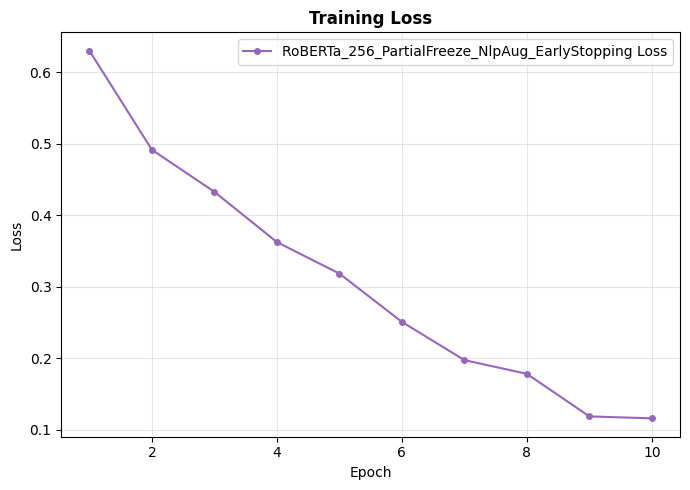

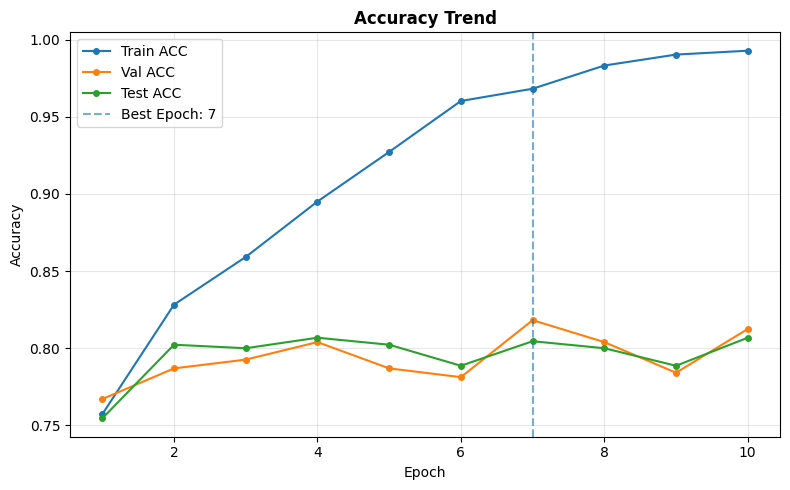

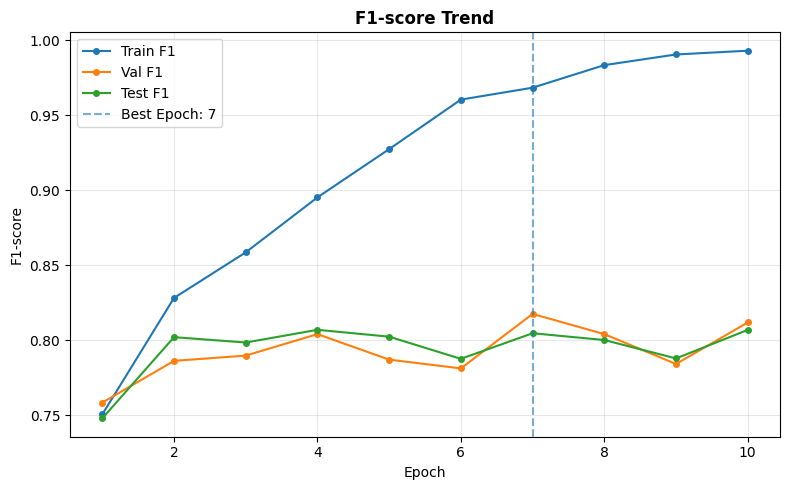


[Best Model 기준 최종 성능 비교]
RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping | Best Epoch: 7 | Best Val F1: 0.8174 | Final Test Accuracy: 0.8045 | Final Test Precision: 0.8045 | Final Test Recall: 0.8045 | Final Test F1: 0.8045

[Epoch별 과적합 Gap 확인, Train F1 - Val F1]

[RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping]
Epoch 01 | Train F1: 0.7504 | Val F1: 0.7583 | Test F1: 0.7478 | Gap: -0.0079
Epoch 02 | Train F1: 0.8281 | Val F1: 0.7861 | Test F1: 0.8019 | Gap: 0.0420
Epoch 03 | Train F1: 0.8585 | Val F1: 0.7896 | Test F1: 0.7983 | Gap: 0.0688
Epoch 04 | Train F1: 0.8951 | Val F1: 0.8039 | Test F1: 0.8068 | Gap: 0.0912
Epoch 05 | Train F1: 0.9273 | Val F1: 0.7869 | Test F1: 0.8022 | Gap: 0.1403
Epoch 06 | Train F1: 0.9603 | Val F1: 0.7811 | Test F1: 0.7875 | Gap: 0.1792
Epoch 07 | Train F1: 0.9682 | Val F1: 0.8174 | Test F1: 0.8045 | Gap: 0.1508
Epoch 08 | Train F1: 0.9833 | Val F1: 0.8039 | Test F1: 0.8000 | Gap: 0.1793
Epoch 09 | Train F1: 0.9904 | Val F1: 0.7840 | Test F1: 0.7877 | Gap:

In [ ]:
# ── 3) 시각화, Train / Val / Test 성능 비교 ──

colors = {
    "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping": "tab:purple"
}


# -----------------------------
# 1. Training Loss 그래프
# -----------------------------
plt.figure(figsize=(7, 5))

for tag_name, res in all_results.items():
    c = colors.get(tag_name, "gray")
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(
        ep,
        res["loss"],
        color=c,
        marker="o",
        ms=4,
        label=f"{tag_name} Loss"
    )

plt.title("Training Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Accuracy 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_acc"], marker="o", ms=4, label="Train ACC")
    plt.plot(ep, res["val_acc"], marker="o", ms=4, label="Val ACC")
    plt.plot(ep, res["test_acc"], marker="o", ms=4, label="Test ACC")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("Accuracy Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. F1-score 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_f1"], marker="o", ms=4, label="Train F1")
    plt.plot(ep, res["val_f1"], marker="o", ms=4, label="Val F1")
    plt.plot(ep, res["test_f1"], marker="o", ms=4, label="Test F1")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("F1-score Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Best Model 기준 최종 성능 출력
# -----------------------------
print("\n[Best Model 기준 최종 성능 비교]")

for tag_name, res in all_results.items():
    print(
        f"{tag_name} | "
        f"Best Epoch: {res['best_epoch']} | "
        f"Best Val F1: {res['best_val_f1']:.4f} | "
        f"Final Test Accuracy: {res['best_test_acc']:.4f} | "
        f"Final Test Precision: {res['best_test_precision']:.4f} | "
        f"Final Test Recall: {res['best_test_recall']:.4f} | "
        f"Final Test F1: {res['best_test_f1']:.4f}"
    )


# -----------------------------
# 5. 과적합 Gap 확인
# -----------------------------
print("\n[Epoch별 과적합 Gap 확인, Train F1 - Val F1]")

for tag_name, res in all_results.items():
    print(f"\n[{tag_name}]")

    for i in range(len(res["train_f1"])):
        train_f1 = res["train_f1"][i]
        val_f1 = res["val_f1"][i]
        test_f1 = res["test_f1"][i]

        gap = train_f1 - val_f1

        print(
            f"Epoch {i+1:02d} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f}"
        )

결과: 이번 성능의 결과 과적합 발생 O 
epoch 5 : 과적합 발생 X => epocg >5 일때부터 과적합 발생 시작O
epoch 최대 + 조기종료 + 데이터 증강 : 약간 과적합  발생 O
why? 과적합 여전히 발생?
=> 조기종료는 과적합 예방이 아닌 감지 후 중단하는 방식
: 조기 종료하는 과정에서 patience 떄문에 과적합 발생한 것이라 예상 => patience 3-> 2로 줄여보자!


변경사항 
patience를 3 → 2
dropout을 0.2 → 0.3
weight_decay를 조금 키우기
learning rate를 낮추기
unfreeze_last_n을 4 → 2

In [7]:
# ── 2) RoBERTa 일부 레이어 동결 + 256차원 Projection + Early Stopping, 과적합 완화 강화 버전 ──

import copy
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


class RoBERTaPartialFreezeModel(nn.Module):
    def __init__(
        self,
        model_name=MODEL_NAME,
        nclass=len(label2id),
        feature_dim=256,
        unfreeze_last_n=2
    ):
        super().__init__()

        self.roberta = AutoModel.from_pretrained(model_name)

        # -------------------------------------
        # 1. RoBERTa 전체 먼저 동결
        # -------------------------------------
        for param in self.roberta.parameters():
            param.requires_grad = False

        # -------------------------------------
        # 2. 마지막 n개 encoder layer만 학습 가능하게 풀기
        # 기존 4개 → 2개로 줄여서 과적합 완화
        # -------------------------------------
        for param in self.roberta.encoder.layer[-unfreeze_last_n:].parameters():
            param.requires_grad = True

        hidden_size = self.roberta.config.hidden_size  # roberta-base = 768

        # -------------------------------------
        # 3. 768차원 → 256차원 projection
        # -------------------------------------
        self.feature_layer = nn.Linear(hidden_size, feature_dim)

        self.relu = nn.ReLU()

        # dropout 0.2 → 0.3으로 증가
        self.dropout = nn.Dropout(0.3)

        # 256차원 → class 개수
        self.classifier = nn.Linear(feature_dim, nclass)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        # -------------------------------------
        # Mean Pooling, padding 부분 제외
        # -------------------------------------
        mask = attention_mask.unsqueeze(-1).float()
        masked_hidden = hidden * mask

        sum_hidden = masked_hidden.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1e-9)

        sentence_output = sum_hidden / lengths

        # 768 → 256
        features = self.feature_layer(sentence_output)
        features = self.relu(features)
        features = self.dropout(features)

        logits = self.classifier(features)

        return logits


def eval_metrics(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for input_ids, attention_mask, yb in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            logits = model(input_ids, attention_mask)
            pred = logits.argmax(dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1


models = {
    "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Regularized": RoBERTaPartialFreezeModel(
        unfreeze_last_n=2
    )
}

all_results = {}

for tag, model in models.items():
    model = model.to(device)

    print(f"\n{'=' * 40}  {tag}  {'=' * 40}")

    # -----------------------------
    # 파라미터 수 확인
    # -----------------------------
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params_count = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    frozen_params_count = total_params - trainable_params_count

    print(f"전체 파라미터 수: {total_params:,}")
    print(f"학습되는 파라미터 수: {trainable_params_count:,}")
    print(f"동결된 파라미터 수: {frozen_params_count:,}")
    print("구조: RoBERTa 마지막 2개 layer 학습 + Mean Pooling + 256차원 projection + Classifier")
    print("목표: 과적합 완화")
    print("조기 종료 기준: Validation F1")

    # -----------------------------
    # Optimizer 설정
    # RoBERTa 마지막 layer는 더 작은 lr
    # 새로 붙인 head도 기존보다 낮은 lr
    # weight_decay 증가
    # -----------------------------
    roberta_params = [
        p for n, p in model.roberta.named_parameters()
        if p.requires_grad
    ]

    head_params = (
        list(model.feature_layer.parameters())
        + list(model.classifier.parameters())
    )

    opt = torch.optim.AdamW(
        [
            {"params": roberta_params, "lr": 5e-6},
            {"params": head_params, "lr": 5e-5}
        ],
        weight_decay=0.03
    )

    # -----------------------------
    # Class Weight 적용
    # -----------------------------
    y_train_np = train_labels_tensor.cpu().numpy()
    nclass = len(label2id)

    class_counts = np.bincount(y_train_np, minlength=nclass)
    total_count = len(y_train_np)

    class_weights = total_count / (nclass * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    print("class counts:", class_counts)
    print("class weights:", class_weights)

    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = {
        "loss": [],

        "train_acc": [],
        "val_acc": [],
        "test_acc": [],

        "train_precision": [],
        "val_precision": [],
        "test_precision": [],

        "train_recall": [],
        "val_recall": [],
        "test_recall": [],

        "train_f1": [],
        "val_f1": [],
        "test_f1": [],

        "best_epoch": None,

        "best_val_acc": None,
        "best_val_precision": None,
        "best_val_recall": None,
        "best_val_f1": None,

        "best_test_acc": None,
        "best_test_precision": None,
        "best_test_recall": None,
        "best_test_f1": None
    }

    # -----------------------------
    # Early Stopping 설정
    # patience 3 → 2로 줄임
    # -----------------------------
    EPOCHS = 20
    patience = 2
    min_delta = 0.0001

    best_val_f1 = 0
    best_epoch = 0

    best_val_acc = 0
    best_val_precision = 0
    best_val_recall = 0

    patience_counter = 0
    best_model_state = None

    # -----------------------------
    # 학습 시작
    # -----------------------------
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for input_ids, attention_mask, yb in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            opt.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = crit(logits, yb)

            loss.backward()

            # gradient 폭주 방지
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            opt.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_acc, train_precision, train_recall, train_f1 = eval_metrics(
            model,
            train_loader
        )

        val_acc, val_precision, val_recall, val_f1 = eval_metrics(
            model,
            val_loader
        )

        test_acc, test_precision, test_recall, test_f1 = eval_metrics(
            model,
            test_loader
        )

        hist["loss"].append(epoch_loss)

        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)
        hist["test_acc"].append(test_acc)

        hist["train_precision"].append(train_precision)
        hist["val_precision"].append(val_precision)
        hist["test_precision"].append(test_precision)

        hist["train_recall"].append(train_recall)
        hist["val_recall"].append(val_recall)
        hist["test_recall"].append(test_recall)

        hist["train_f1"].append(train_f1)
        hist["val_f1"].append(val_f1)
        hist["test_f1"].append(test_f1)

        gap = train_f1 - val_f1

        print(
            f"Epoch {epoch:02d} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f} | "
            f"Train ACC: {train_acc:.4f} | "
            f"Val ACC: {val_acc:.4f} | "
            f"Test ACC: {test_acc:.4f}"
        )

        # -----------------------------
        # Validation F1 기준 Early Stopping
        # -----------------------------
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_epoch = epoch

            best_val_acc = val_acc
            best_val_precision = val_precision
            best_val_recall = val_recall

            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())

            print(f"Best model updated! Best Val F1: {best_val_f1:.4f}")

        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}!")
            print(f"Best epoch: {best_epoch}")
            print(f"Best Val F1: {best_val_f1:.4f}")
            break

    # -----------------------------
    # Best model 복원
    # -----------------------------
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\nBest model state loaded.")

    # 복원된 best model로 최종 test 성능 다시 계산
    final_test_acc, final_test_precision, final_test_recall, final_test_f1 = eval_metrics(
        model,
        test_loader
    )

    hist["best_epoch"] = best_epoch

    hist["best_val_acc"] = best_val_acc
    hist["best_val_precision"] = best_val_precision
    hist["best_val_recall"] = best_val_recall
    hist["best_val_f1"] = best_val_f1

    hist["best_test_acc"] = final_test_acc
    hist["best_test_precision"] = final_test_precision
    hist["best_test_recall"] = final_test_recall
    hist["best_test_f1"] = final_test_f1

    all_results[tag] = hist

    print("\n[Best Model 기준 최종 성능]")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")
    print(f"Best Val Precision: {best_val_precision:.4f}")
    print(f"Best Val Recall: {best_val_recall:.4f}")
    print(f"Best Val F1: {best_val_f1:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")
    print(f"Final Test Precision: {final_test_precision:.4f}")
    print(f"Final Test Recall: {final_test_recall:.4f}")
    print(f"Final Test F1: {final_test_f1:.4f}")

    print(f"\n저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



========================================  RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Regularized  ========================================
전체 파라미터 수: 124,843,010
학습되는 파라미터 수: 14,373,122
동결된 파라미터 수: 110,469,888
구조: RoBERTa 마지막 2개 layer 학습 + Mean Pooling + 256차원 projection + Classifier
목표: 과적합 완화
조기 종료 기준: Validation F1
class counts: [1208 1185]
class weights: tensor([0.9905, 1.0097])
Epoch 01 | Loss: 0.6879 | Train F1: 0.6702 | Val F1: 0.6649 | Test F1: 0.6198 | Gap: 0.0053 | Train ACC: 0.6766 | Val ACC: 0.6733 | Test ACC: 0.6273
Best model updated! Best Val F1: 0.6649
Epoch 02 | Loss: 0.6277 | Train F1: 0.7429 | Val F1: 0.7529 | Test F1: 0.7227 | Gap: -0.0099 | Train ACC: 0.7430 | Val ACC: 0.7528 | Test ACC: 0.7227
Best model updated! Best Val F1: 0.7529
Epoch 03 | Loss: 0.5273 | Train F1: 0.7791 | Val F1: 0.7984 | Test F1: 0.7644 | Gap: -0.0193 | Train ACC: 0.7810 | Val ACC: 0.8011 | Test ACC: 0.7659
Best model updated! Best Val F1: 0.7984
Epoch 04 | Loss: 0.4959 | Train F1: 0.80

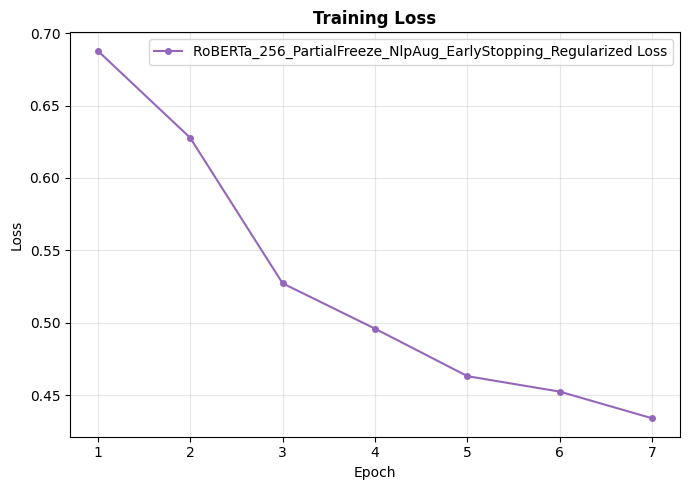

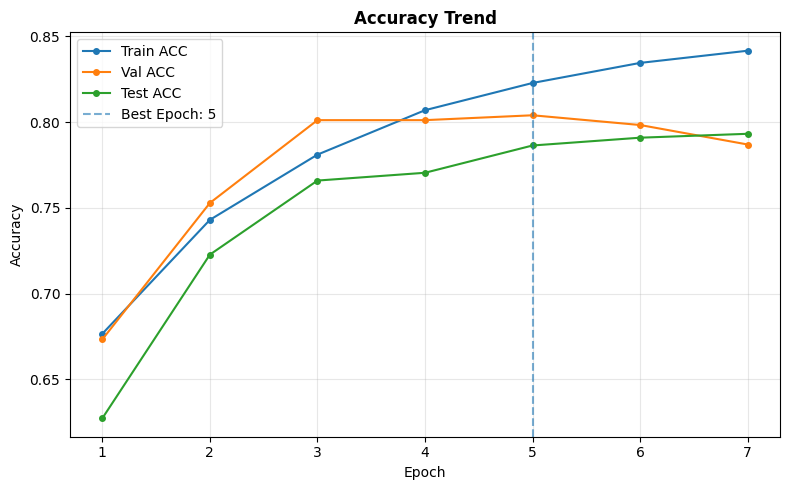

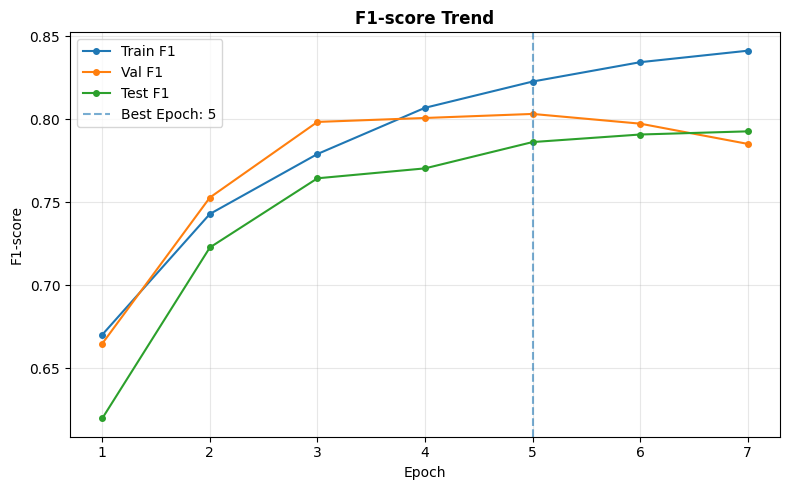


[Best Model 기준 최종 성능 비교]
RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Regularized | Best Epoch: 5 | Best Val F1: 0.8032 | Final Test Accuracy: 0.7864 | Final Test Precision: 0.7865 | Final Test Recall: 0.7864 | Final Test F1: 0.7863

[Epoch별 과적합 Gap 확인, Train F1 - Val F1]

[RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Regularized]
Epoch 01 | Train F1: 0.6702 | Val F1: 0.6649 | Test F1: 0.6198 | Gap: 0.0053
Epoch 02 | Train F1: 0.7429 | Val F1: 0.7529 | Test F1: 0.7227 | Gap: -0.0099
Epoch 03 | Train F1: 0.7791 | Val F1: 0.7984 | Test F1: 0.7644 | Gap: -0.0193
Epoch 04 | Train F1: 0.8069 | Val F1: 0.8008 | Test F1: 0.7704 | Gap: 0.0061
Epoch 05 | Train F1: 0.8227 | Val F1: 0.8032 | Test F1: 0.7863 | Gap: 0.0195
Epoch 06 | Train F1: 0.8344 | Val F1: 0.7974 | Test F1: 0.7908 | Gap: 0.0370
Epoch 07 | Train F1: 0.8413 | Val F1: 0.7852 | Test F1: 0.7927 | Gap: 0.0562


In [8]:
# ── 3) 시각화, Train / Val / Test 성능 비교 ──

colors = {
    "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Regularized": "tab:purple"
}


# -----------------------------
# 1. Training Loss 그래프
# -----------------------------
plt.figure(figsize=(7, 5))

for tag_name, res in all_results.items():
    c = colors.get(tag_name, "gray")
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(
        ep,
        res["loss"],
        color=c,
        marker="o",
        ms=4,
        label=f"{tag_name} Loss"
    )

plt.title("Training Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Accuracy 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_acc"], marker="o", ms=4, label="Train ACC")
    plt.plot(ep, res["val_acc"], marker="o", ms=4, label="Val ACC")
    plt.plot(ep, res["test_acc"], marker="o", ms=4, label="Test ACC")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("Accuracy Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. F1-score 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_f1"], marker="o", ms=4, label="Train F1")
    plt.plot(ep, res["val_f1"], marker="o", ms=4, label="Val F1")
    plt.plot(ep, res["test_f1"], marker="o", ms=4, label="Test F1")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("F1-score Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Best Model 기준 최종 성능 출력
# -----------------------------
print("\n[Best Model 기준 최종 성능 비교]")

for tag_name, res in all_results.items():
    print(
        f"{tag_name} | "
        f"Best Epoch: {res['best_epoch']} | "
        f"Best Val F1: {res['best_val_f1']:.4f} | "
        f"Final Test Accuracy: {res['best_test_acc']:.4f} | "
        f"Final Test Precision: {res['best_test_precision']:.4f} | "
        f"Final Test Recall: {res['best_test_recall']:.4f} | "
        f"Final Test F1: {res['best_test_f1']:.4f}"
    )


# -----------------------------
# 5. 과적합 Gap 확인
# -----------------------------
print("\n[Epoch별 과적합 Gap 확인, Train F1 - Val F1]")

for tag_name, res in all_results.items():
    print(f"\n[{tag_name}]")

    for i in range(len(res["train_f1"])):
        train_f1 = res["train_f1"][i]
        val_f1 = res["val_f1"][i]
        test_f1 = res["test_f1"][i]

        gap = train_f1 - val_f1

        print(
            f"Epoch {i+1:02d} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f}"
        )

과적합을 줄이기 위해 성능 조절 한것이 모델이 덜 학습하게 한것,,,

unfreeze_last_n = 3
dropout = 0.25
roberta lr = 1e-5
head lr = 1e-4
weight_decay = 0.02
patience = 3

In [9]:
# ── 2) RoBERTa 일부 레이어 동결 + 256차원 Projection + Early Stopping, 중간값 버전 ──

import copy
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


class RoBERTaPartialFreezeModel(nn.Module):
    def __init__(
        self,
        model_name=MODEL_NAME,
        nclass=len(label2id),
        feature_dim=256,
        unfreeze_last_n=3
    ):
        super().__init__()

        self.roberta = AutoModel.from_pretrained(model_name)

        # -------------------------------------
        # 1. RoBERTa 전체 먼저 동결
        # -------------------------------------
        for param in self.roberta.parameters():
            param.requires_grad = False

        # -------------------------------------
        # 2. 마지막 3개 encoder layer만 학습 가능하게 풀기
        # roberta-base는 총 12개 encoder layer
        # layer 0~8: 동결
        # layer 9~11: 학습
        # -------------------------------------
        for param in self.roberta.encoder.layer[-unfreeze_last_n:].parameters():
            param.requires_grad = True

        hidden_size = self.roberta.config.hidden_size  # roberta-base = 768

        # -------------------------------------
        # 3. 768차원 → 256차원 projection
        # -------------------------------------
        self.feature_layer = nn.Linear(hidden_size, feature_dim)

        self.relu = nn.ReLU()

        # dropout 중간값
        self.dropout = nn.Dropout(0.25)

        # 256차원 → class 개수
        self.classifier = nn.Linear(feature_dim, nclass)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        # -------------------------------------
        # Mean Pooling, padding 부분 제외
        # -------------------------------------
        mask = attention_mask.unsqueeze(-1).float()
        masked_hidden = hidden * mask

        sum_hidden = masked_hidden.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1e-9)

        sentence_output = sum_hidden / lengths  # [batch_size, 768]

        # 768 → 256
        features = self.feature_layer(sentence_output)
        features = self.relu(features)
        features = self.dropout(features)

        logits = self.classifier(features)

        return logits


def eval_metrics(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for input_ids, attention_mask, yb in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            logits = model(input_ids, attention_mask)
            pred = logits.argmax(dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1


models = {
    "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Mid": RoBERTaPartialFreezeModel(
        unfreeze_last_n=3
    )
}

all_results = {}

for tag, model in models.items():
    model = model.to(device)

    print(f"\n{'=' * 40}  {tag}  {'=' * 40}")

    # -----------------------------
    # 파라미터 수 확인
    # -----------------------------
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params_count = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    frozen_params_count = total_params - trainable_params_count

    print(f"전체 파라미터 수: {total_params:,}")
    print(f"학습되는 파라미터 수: {trainable_params_count:,}")
    print(f"동결된 파라미터 수: {frozen_params_count:,}")
    print("구조: RoBERTa 마지막 3개 layer 학습 + Mean Pooling + 256차원 projection + Classifier")
    print("목표: 성능과 과적합 완화의 균형")
    print("조기 종료 기준: Validation F1")

    # -----------------------------
    # Optimizer 설정, 중간값
    # RoBERTa 마지막 layer는 작은 lr
    # 새로 붙인 projection/classifier는 조금 큰 lr
    # -----------------------------
    roberta_params = [
        p for n, p in model.roberta.named_parameters()
        if p.requires_grad
    ]

    head_params = (
        list(model.feature_layer.parameters())
        + list(model.classifier.parameters())
    )

    opt = torch.optim.AdamW(
        [
            {"params": roberta_params, "lr": 1e-5},
            {"params": head_params, "lr": 1e-4}
        ],
        weight_decay=0.02
    )

    # -----------------------------
    # Class Weight 적용
    # -----------------------------
    y_train_np = train_labels_tensor.cpu().numpy()
    nclass = len(label2id)

    class_counts = np.bincount(y_train_np, minlength=nclass)
    total_count = len(y_train_np)

    class_weights = total_count / (nclass * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    print("class counts:", class_counts)
    print("class weights:", class_weights)

    crit = nn.CrossEntropyLoss(weight=class_weights)

    hist = {
        "loss": [],

        "train_acc": [],
        "val_acc": [],
        "test_acc": [],

        "train_precision": [],
        "val_precision": [],
        "test_precision": [],

        "train_recall": [],
        "val_recall": [],
        "test_recall": [],

        "train_f1": [],
        "val_f1": [],
        "test_f1": [],

        "best_epoch": None,

        "best_val_acc": None,
        "best_val_precision": None,
        "best_val_recall": None,
        "best_val_f1": None,

        "best_test_acc": None,
        "best_test_precision": None,
        "best_test_recall": None,
        "best_test_f1": None
    }

    # -----------------------------
    # Early Stopping 설정
    # -----------------------------
    EPOCHS = 20
    patience = 3
    min_delta = 0.0001

    best_val_f1 = 0
    best_epoch = 0

    best_val_acc = 0
    best_val_precision = 0
    best_val_recall = 0

    patience_counter = 0
    best_model_state = None

    # -----------------------------
    # 학습 시작
    # -----------------------------
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for input_ids, attention_mask, yb in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            opt.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = crit(logits, yb)

            loss.backward()

            # gradient 폭주 방지
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            opt.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_acc, train_precision, train_recall, train_f1 = eval_metrics(
            model,
            train_loader
        )

        val_acc, val_precision, val_recall, val_f1 = eval_metrics(
            model,
            val_loader
        )

        test_acc, test_precision, test_recall, test_f1 = eval_metrics(
            model,
            test_loader
        )

        hist["loss"].append(epoch_loss)

        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)
        hist["test_acc"].append(test_acc)

        hist["train_precision"].append(train_precision)
        hist["val_precision"].append(val_precision)
        hist["test_precision"].append(test_precision)

        hist["train_recall"].append(train_recall)
        hist["val_recall"].append(val_recall)
        hist["test_recall"].append(test_recall)

        hist["train_f1"].append(train_f1)
        hist["val_f1"].append(val_f1)
        hist["test_f1"].append(test_f1)

        gap = train_f1 - val_f1

        print(
            f"Epoch {epoch:02d} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f} | "
            f"Train ACC: {train_acc:.4f} | "
            f"Val ACC: {val_acc:.4f} | "
            f"Test ACC: {test_acc:.4f}"
        )

        # -----------------------------
        # Validation F1 기준 Early Stopping
        # -----------------------------
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_epoch = epoch

            best_val_acc = val_acc
            best_val_precision = val_precision
            best_val_recall = val_recall

            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())

            print(f"Best model updated! Best Val F1: {best_val_f1:.4f}")

        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}!")
            print(f"Best epoch: {best_epoch}")
            print(f"Best Val F1: {best_val_f1:.4f}")
            break

    # -----------------------------
    # Best model 복원
    # -----------------------------
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\nBest model state loaded.")

    # 복원된 best model로 최종 test 성능 다시 계산
    final_test_acc, final_test_precision, final_test_recall, final_test_f1 = eval_metrics(
        model,
        test_loader
    )

    hist["best_epoch"] = best_epoch

    hist["best_val_acc"] = best_val_acc
    hist["best_val_precision"] = best_val_precision
    hist["best_val_recall"] = best_val_recall
    hist["best_val_f1"] = best_val_f1

    hist["best_test_acc"] = final_test_acc
    hist["best_test_precision"] = final_test_precision
    hist["best_test_recall"] = final_test_recall
    hist["best_test_f1"] = final_test_f1

    all_results[tag] = hist

    print("\n[Best Model 기준 최종 성능]")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")
    print(f"Best Val Precision: {best_val_precision:.4f}")
    print(f"Best Val Recall: {best_val_recall:.4f}")
    print(f"Best Val F1: {best_val_f1:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")
    print(f"Final Test Precision: {final_test_precision:.4f}")
    print(f"Final Test Recall: {final_test_recall:.4f}")
    print(f"Final Test F1: {final_test_f1:.4f}")

    print(f"\n저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



========================================  RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Mid  ========================================
전체 파라미터 수: 124,843,010
학습되는 파라미터 수: 21,460,994
동결된 파라미터 수: 103,382,016
구조: RoBERTa 마지막 3개 layer 학습 + Mean Pooling + 256차원 projection + Classifier
목표: 성능과 과적합 완화의 균형
조기 종료 기준: Validation F1
class counts: [1208 1185]
class weights: tensor([0.9905, 1.0097])
Epoch 01 | Loss: 0.6520 | Train F1: 0.7481 | Val F1: 0.7243 | Test F1: 0.7388 | Gap: 0.0239 | Train ACC: 0.7509 | Val ACC: 0.7273 | Test ACC: 0.7409
Best model updated! Best Val F1: 0.7243
Epoch 02 | Loss: 0.5013 | Train F1: 0.8174 | Val F1: 0.7954 | Test F1: 0.8000 | Gap: 0.0220 | Train ACC: 0.8174 | Val ACC: 0.7955 | Test ACC: 0.8000
Best model updated! Best Val F1: 0.7954
Epoch 03 | Loss: 0.4499 | Train F1: 0.8486 | Val F1: 0.7915 | Test F1: 0.8044 | Gap: 0.0571 | Train ACC: 0.8487 | Val ACC: 0.7926 | Test ACC: 0.8045
No improvement. Patience: 1/3
Epoch 04 | Loss: 0.3991 | Train F1: 0.8817 | Val F1:

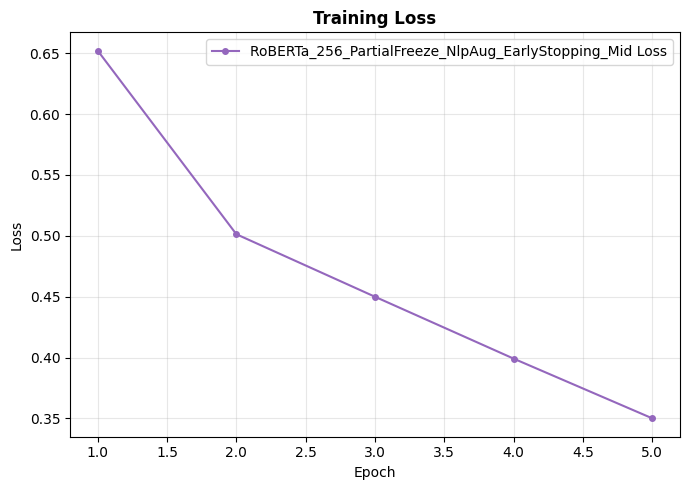

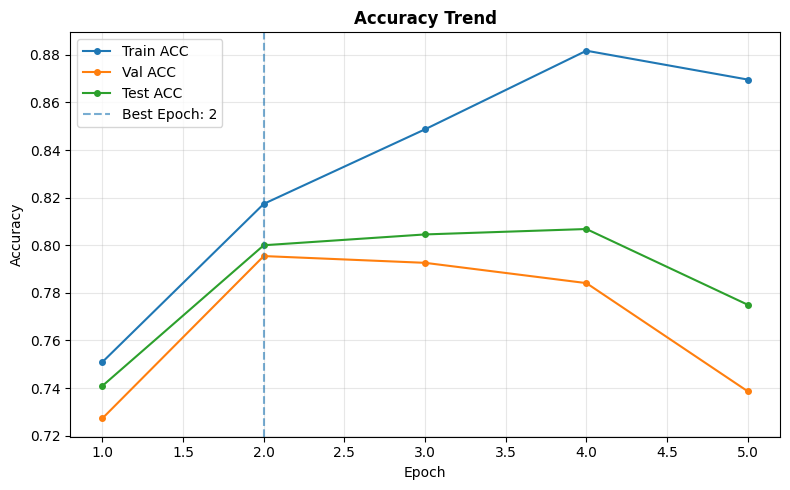

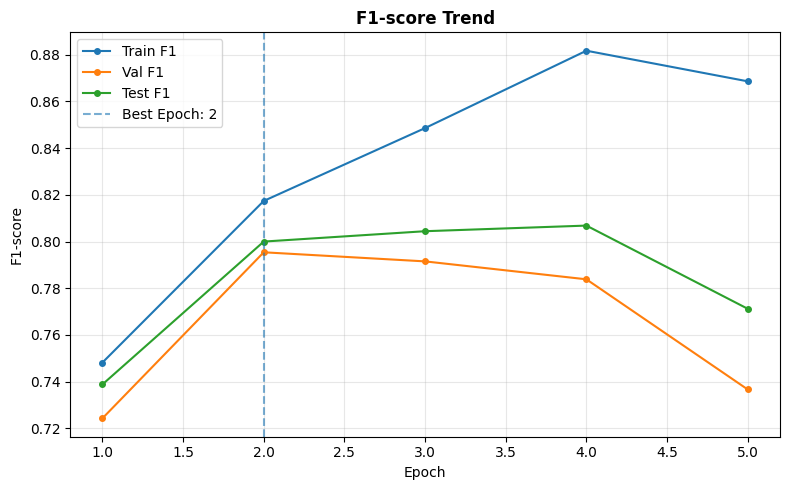


[Best Model 기준 최종 성능 비교]
RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Mid | Best Epoch: 2 | Best Val F1: 0.7954 | Final Test Accuracy: 0.8000 | Final Test Precision: 0.8008 | Final Test Recall: 0.8000 | Final Test F1: 0.8000

[Epoch별 과적합 Gap 확인, Train F1 - Val F1]

[RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Mid]
Epoch 01 | Train F1: 0.7481 | Val F1: 0.7243 | Test F1: 0.7388 | Gap: 0.0239
Epoch 02 | Train F1: 0.8174 | Val F1: 0.7954 | Test F1: 0.8000 | Gap: 0.0220
Epoch 03 | Train F1: 0.8486 | Val F1: 0.7915 | Test F1: 0.8044 | Gap: 0.0571
Epoch 04 | Train F1: 0.8817 | Val F1: 0.7838 | Test F1: 0.8068 | Gap: 0.0979
Epoch 05 | Train F1: 0.8686 | Val F1: 0.7366 | Test F1: 0.7712 | Gap: 0.1320


In [10]:
# ── 3) 시각화, Train / Val / Test 성능 비교 ──

colors = {
    "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Mid": "tab:purple"
}


# -----------------------------
# 1. Training Loss 그래프
# -----------------------------
plt.figure(figsize=(7, 5))

for tag_name, res in all_results.items():
    c = colors.get(tag_name, "gray")
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(
        ep,
        res["loss"],
        color=c,
        marker="o",
        ms=4,
        label=f"{tag_name} Loss"
    )

plt.title("Training Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Accuracy 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_acc"], marker="o", ms=4, label="Train ACC")
    plt.plot(ep, res["val_acc"], marker="o", ms=4, label="Val ACC")
    plt.plot(ep, res["test_acc"], marker="o", ms=4, label="Test ACC")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("Accuracy Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. F1-score 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_f1"], marker="o", ms=4, label="Train F1")
    plt.plot(ep, res["val_f1"], marker="o", ms=4, label="Val F1")
    plt.plot(ep, res["test_f1"], marker="o", ms=4, label="Test F1")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("F1-score Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Best Model 기준 최종 성능 출력
# -----------------------------
print("\n[Best Model 기준 최종 성능 비교]")

for tag_name, res in all_results.items():
    print(
        f"{tag_name} | "
        f"Best Epoch: {res['best_epoch']} | "
        f"Best Val F1: {res['best_val_f1']:.4f} | "
        f"Final Test Accuracy: {res['best_test_acc']:.4f} | "
        f"Final Test Precision: {res['best_test_precision']:.4f} | "
        f"Final Test Recall: {res['best_test_recall']:.4f} | "
        f"Final Test F1: {res['best_test_f1']:.4f}"
    )


# -----------------------------
# 5. 과적합 Gap 확인
# -----------------------------
print("\n[Epoch별 과적합 Gap 확인, Train F1 - Val F1]")

for tag_name, res in all_results.items():
    print(f"\n[{tag_name}]")

    for i in range(len(res["train_f1"])):
        train_f1 = res["train_f1"][i]
        val_f1 = res["val_f1"][i]
        test_f1 = res["test_f1"][i]

        gap = train_f1 - val_f1

        print(
            f"Epoch {i+1:02d} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f}"
        )

너무 규제를 강하게 주면 성능이 떨어지고, 규제를 약하게 주면 성능은 좋은데 과적합 gap이 커지는 상태


RoBERTa 마지막 4개 layer 학습
+ 256차원 projection
+ nlpaug 유의어 교체 증강
+ dropout 0.25
+ weight_decay 0.015
+ roberta lr 8e-6
+ head lr 8e-5
+ validation F1 기준 early stopping

In [11]:
# ── 2) RoBERTa 일부 레이어 동결 + 256차원 Projection + Early Stopping, 성능/과적합 균형 버전 ──

import copy
import torch
import torch.nn as nn
from transformers import AutoModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


class RoBERTaPartialFreezeModel(nn.Module):
    def __init__(
        self,
        model_name=MODEL_NAME,
        nclass=len(label2id),
        feature_dim=256,
        unfreeze_last_n=4
    ):
        super().__init__()

        self.roberta = AutoModel.from_pretrained(model_name)

        # -------------------------------------
        # 1. RoBERTa 전체 먼저 동결
        # -------------------------------------
        for param in self.roberta.parameters():
            param.requires_grad = False

        # -------------------------------------
        # 2. 마지막 4개 encoder layer만 학습
        # roberta-base는 총 12개 encoder layer
        # layer 0~7: 동결
        # layer 8~11: 학습
        # -------------------------------------
        for param in self.roberta.encoder.layer[-unfreeze_last_n:].parameters():
            param.requires_grad = True

        hidden_size = self.roberta.config.hidden_size  # roberta-base = 768

        # -------------------------------------
        # 3. 768차원 → 256차원 Projection
        # -------------------------------------
        self.feature_layer = nn.Linear(hidden_size, feature_dim)
        self.relu = nn.ReLU()

        # 기존 0.2보다 살짝 강화, 0.3보다는 약하게
        self.dropout = nn.Dropout(0.25)

        # 256차원 → class 개수
        self.classifier = nn.Linear(feature_dim, nclass)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # outputs.last_hidden_state: [batch_size, max_len, 768]
        hidden = outputs.last_hidden_state

        # -------------------------------------
        # Mean Pooling, padding 제외
        # -------------------------------------
        mask = attention_mask.unsqueeze(-1).float()
        masked_hidden = hidden * mask

        sum_hidden = masked_hidden.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1e-9)

        sentence_output = sum_hidden / lengths  # [batch_size, 768]

        # 768 → 256
        features = self.feature_layer(sentence_output)
        features = self.relu(features)
        features = self.dropout(features)

        logits = self.classifier(features)

        return logits


def eval_metrics(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for input_ids, attention_mask, yb in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            logits = model(input_ids, attention_mask)
            pred = logits.argmax(dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1


models = {
    "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Tuned": RoBERTaPartialFreezeModel(
        unfreeze_last_n=4
    )
}

all_results = {}

for tag, model in models.items():
    model = model.to(device)

    print(f"\n{'=' * 40}  {tag}  {'=' * 40}")

    # -----------------------------
    # 파라미터 수 확인
    # -----------------------------
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params_count = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    frozen_params_count = total_params - trainable_params_count

    print(f"전체 파라미터 수: {total_params:,}")
    print(f"학습되는 파라미터 수: {trainable_params_count:,}")
    print(f"동결된 파라미터 수: {frozen_params_count:,}")
    print("구조: RoBERTa 마지막 4개 layer 학습 + Mean Pooling + 256차원 Projection + Classifier")
    print("목표: 기존 4-layer 성능 유지 + 과적합 완화")
    print("조기 종료 기준: Validation F1")

    # -----------------------------
    # Optimizer 설정
    # RoBERTa는 살짝 낮은 lr
    # 새로 붙인 projection/classifier는 조금 큰 lr
    # weight_decay는 0.01과 0.03 사이 중간값
    # -----------------------------
    roberta_params = [
        p for n, p in model.roberta.named_parameters()
        if p.requires_grad
    ]

    head_params = (
        list(model.feature_layer.parameters())
        + list(model.classifier.parameters())
    )

    opt = torch.optim.AdamW(
        [
            {"params": roberta_params, "lr": 8e-6},
            {"params": head_params, "lr": 8e-5}
        ],
        weight_decay=0.015
    )

    # -----------------------------
    # Loss 함수
    # class imbalance가 심하지 않다면 weight 없이 먼저 실험 추천
    # -----------------------------
    crit = nn.CrossEntropyLoss()

    hist = {
        "loss": [],

        "train_acc": [],
        "val_acc": [],
        "test_acc": [],

        "train_precision": [],
        "val_precision": [],
        "test_precision": [],

        "train_recall": [],
        "val_recall": [],
        "test_recall": [],

        "train_f1": [],
        "val_f1": [],
        "test_f1": [],

        "best_epoch": None,

        "best_val_acc": None,
        "best_val_precision": None,
        "best_val_recall": None,
        "best_val_f1": None,

        "best_test_acc": None,
        "best_test_precision": None,
        "best_test_recall": None,
        "best_test_f1": None
    }

    # -----------------------------
    # Early Stopping 설정
    # -----------------------------
    EPOCHS = 20
    patience = 3
    min_delta = 0.0001

    best_val_f1 = 0
    best_epoch = 0

    best_val_acc = 0
    best_val_precision = 0
    best_val_recall = 0

    patience_counter = 0
    best_model_state = None

    # -----------------------------
    # 학습 시작
    # -----------------------------
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for input_ids, attention_mask, yb in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            opt.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = crit(logits, yb)

            loss.backward()

            # gradient 폭주 방지
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            opt.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_acc, train_precision, train_recall, train_f1 = eval_metrics(
            model,
            train_loader
        )

        val_acc, val_precision, val_recall, val_f1 = eval_metrics(
            model,
            val_loader
        )

        test_acc, test_precision, test_recall, test_f1 = eval_metrics(
            model,
            test_loader
        )

        hist["loss"].append(epoch_loss)

        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)
        hist["test_acc"].append(test_acc)

        hist["train_precision"].append(train_precision)
        hist["val_precision"].append(val_precision)
        hist["test_precision"].append(test_precision)

        hist["train_recall"].append(train_recall)
        hist["val_recall"].append(val_recall)
        hist["test_recall"].append(test_recall)

        hist["train_f1"].append(train_f1)
        hist["val_f1"].append(val_f1)
        hist["test_f1"].append(test_f1)

        gap = train_f1 - val_f1

        print(
            f"Epoch {epoch:02d} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f} | "
            f"Train ACC: {train_acc:.4f} | "
            f"Val ACC: {val_acc:.4f} | "
            f"Test ACC: {test_acc:.4f}"
        )

        # -----------------------------
        # Validation F1 기준 Early Stopping
        # -----------------------------
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_epoch = epoch

            best_val_acc = val_acc
            best_val_precision = val_precision
            best_val_recall = val_recall

            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())

            print(f"Best model updated! Best Val F1: {best_val_f1:.4f}")

        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}!")
            print(f"Best epoch: {best_epoch}")
            print(f"Best Val F1: {best_val_f1:.4f}")
            break

    # -----------------------------
    # Best model 복원
    # -----------------------------
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\nBest model state loaded.")

    # 복원된 best model로 최종 test 성능 다시 계산
    final_test_acc, final_test_precision, final_test_recall, final_test_f1 = eval_metrics(
        model,
        test_loader
    )

    hist["best_epoch"] = best_epoch

    hist["best_val_acc"] = best_val_acc
    hist["best_val_precision"] = best_val_precision
    hist["best_val_recall"] = best_val_recall
    hist["best_val_f1"] = best_val_f1

    hist["best_test_acc"] = final_test_acc
    hist["best_test_precision"] = final_test_precision
    hist["best_test_recall"] = final_test_recall
    hist["best_test_f1"] = final_test_f1

    all_results[tag] = hist

    print("\n[Best Model 기준 최종 성능]")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")
    print(f"Best Val Precision: {best_val_precision:.4f}")
    print(f"Best Val Recall: {best_val_recall:.4f}")
    print(f"Best Val F1: {best_val_f1:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")
    print(f"Final Test Precision: {final_test_precision:.4f}")
    print(f"Final Test Recall: {final_test_recall:.4f}")
    print(f"Final Test F1: {final_test_f1:.4f}")

    print(f"\n저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



========================================  RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Tuned  ========================================
전체 파라미터 수: 124,843,010
학습되는 파라미터 수: 28,548,866
동결된 파라미터 수: 96,294,144
구조: RoBERTa 마지막 4개 layer 학습 + Mean Pooling + 256차원 Projection + Classifier
목표: 기존 4-layer 성능 유지 + 과적합 완화
조기 종료 기준: Validation F1
Epoch 01 | Loss: 0.6390 | Train F1: 0.7737 | Val F1: 0.7784 | Test F1: 0.7726 | Gap: -0.0047 | Train ACC: 0.7739 | Val ACC: 0.7784 | Test ACC: 0.7727
Best model updated! Best Val F1: 0.7784
Epoch 02 | Loss: 0.4938 | Train F1: 0.7990 | Val F1: 0.7401 | Test F1: 0.8048 | Gap: 0.0589 | Train ACC: 0.8007 | Val ACC: 0.7415 | Test ACC: 0.8068
No improvement. Patience: 1/3
Epoch 03 | Loss: 0.4486 | Train F1: 0.8445 | Val F1: 0.8068 | Test F1: 0.8023 | Gap: 0.0378 | Train ACC: 0.8445 | Val ACC: 0.8068 | Test ACC: 0.8023
Best model updated! Best Val F1: 0.8068
Epoch 04 | Loss: 0.4020 | Train F1: 0.8711 | Val F1: 0.8004 | Test F1: 0.8021 | Gap: 0.0707 | Train ACC: 

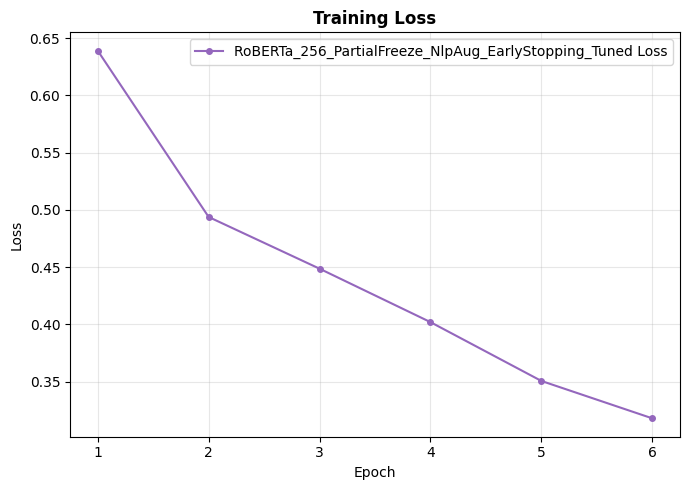

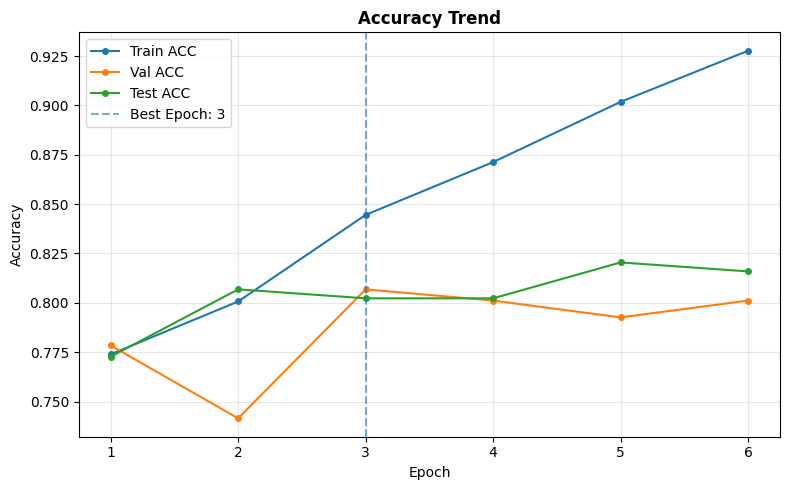

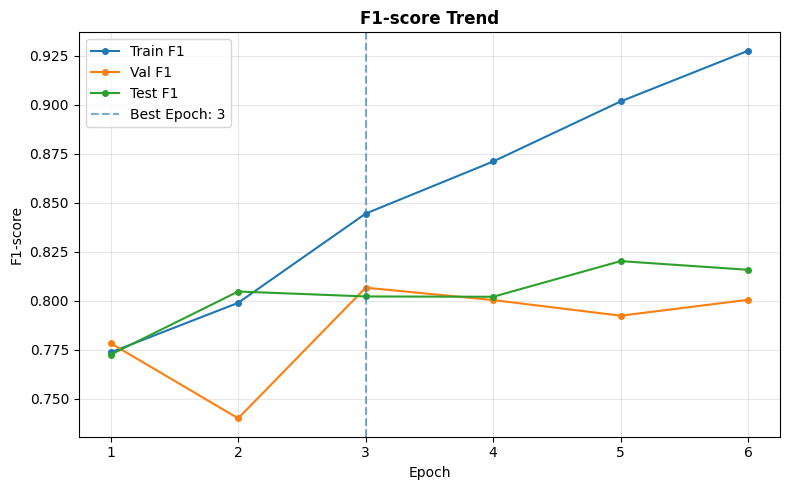


[Best Model 기준 최종 성능 비교]
RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Tuned | Best Epoch: 3 | Best Val F1: 0.8068 | Final Test Accuracy: 0.8023 | Final Test Precision: 0.8027 | Final Test Recall: 0.8023 | Final Test F1: 0.8023

[Epoch별 과적합 Gap 확인, Train F1 - Val F1]

[RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Tuned]
Epoch 01 | Train F1: 0.7737 | Val F1: 0.7784 | Test F1: 0.7726 | Gap: -0.0047
Epoch 02 | Train F1: 0.7990 | Val F1: 0.7401 | Test F1: 0.8048 | Gap: 0.0589
Epoch 03 | Train F1: 0.8445 | Val F1: 0.8068 | Test F1: 0.8023 | Gap: 0.0378
Epoch 04 | Train F1: 0.8711 | Val F1: 0.8004 | Test F1: 0.8021 | Gap: 0.0707
Epoch 05 | Train F1: 0.9018 | Val F1: 0.7925 | Test F1: 0.8203 | Gap: 0.1093
Epoch 06 | Train F1: 0.9277 | Val F1: 0.8006 | Test F1: 0.8159 | Gap: 0.1271


In [12]:
# ── 3) 시각화, Train / Val / Test 성능 비교 ──

colors = {
     "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Tuned": "tab:purple"
}


# -----------------------------
# 1. Training Loss 그래프
# -----------------------------
plt.figure(figsize=(7, 5))

for tag_name, res in all_results.items():
    c = colors.get(tag_name, "gray")
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(
        ep,
        res["loss"],
        color=c,
        marker="o",
        ms=4,
        label=f"{tag_name} Loss"
    )

plt.title("Training Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Accuracy 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_acc"], marker="o", ms=4, label="Train ACC")
    plt.plot(ep, res["val_acc"], marker="o", ms=4, label="Val ACC")
    plt.plot(ep, res["test_acc"], marker="o", ms=4, label="Test ACC")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("Accuracy Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. F1-score 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_f1"], marker="o", ms=4, label="Train F1")
    plt.plot(ep, res["val_f1"], marker="o", ms=4, label="Val F1")
    plt.plot(ep, res["test_f1"], marker="o", ms=4, label="Test F1")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("F1-score Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Best Model 기준 최종 성능 출력
# -----------------------------
print("\n[Best Model 기준 최종 성능 비교]")

for tag_name, res in all_results.items():
    print(
        f"{tag_name} | "
        f"Best Epoch: {res['best_epoch']} | "
        f"Best Val F1: {res['best_val_f1']:.4f} | "
        f"Final Test Accuracy: {res['best_test_acc']:.4f} | "
        f"Final Test Precision: {res['best_test_precision']:.4f} | "
        f"Final Test Recall: {res['best_test_recall']:.4f} | "
        f"Final Test F1: {res['best_test_f1']:.4f}"
    )


# -----------------------------
# 5. 과적합 Gap 확인
# -----------------------------
print("\n[Epoch별 과적합 Gap 확인, Train F1 - Val F1]")

for tag_name, res in all_results.items():
    print(f"\n[{tag_name}]")

    for i in range(len(res["train_f1"])):
        train_f1 = res["train_f1"][i]
        val_f1 = res["val_f1"][i]
        test_f1 = res["test_f1"][i]

        gap = train_f1 - val_f1

        print(
            f"Epoch {i+1:02d} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f}"
        )

전체 RoBERTa fine-tuning + 증강 + early stopping

In [14]:
# ── 1) 데이터 준비 + nlpaug 유의어 교체 증강 + DataLoader 생성 ──

import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"

import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
from IPython.display import display

import nlpaug.augmenter.word as naw


# -----------------------------
# 1. 기본 설정
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "roberta-base"

# 성능을 조금 더 보려면 96 추천
# 기존처럼 쓰고 싶으면 70으로 바꿔도 됨
MAX_LEN = 96

BATCH_SIZE = 16

# 업로드 파일 기준
data_path = r"C:\Users\wanje\Desktop\deeplearning\Raw\mosi_text_metadata.csv"

# 로컬 VSCode에서 실행할 경우 예시
# data_path = r"C:\Users\wanje\Desktop\deeplearning\mosi_text_metadata.csv"


# -----------------------------
# 2. CSV 불러오기
# -----------------------------
df = pd.read_csv(data_path)

print("데이터 크기:", df.shape)
print("컬럼:", df.columns.tolist())
display(df.head())

texts = df["text"].astype(str).tolist()
labels = df["label"].values


# -----------------------------
# 3. label을 0부터 시작하도록 매핑
# -----------------------------
unique_labels = sorted(np.unique(labels))

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

y = np.array([label2id[label] for label in labels], dtype=np.int64)

print("\nlabel2id:", label2id)
print("id2label:", id2label)
print("전체 label 분포:", np.bincount(y, minlength=len(label2id)))


# -----------------------------
# 4. Train / Val / Test 분리
# -----------------------------
indices = np.arange(len(y))

train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.2,
    random_state=SEED,
    stratify=y[train_val_idx]
)

tr_texts = [texts[i] for i in train_idx]
val_texts = [texts[i] for i in val_idx]
test_texts = [texts[i] for i in test_idx]

tr_labels = y[train_idx]
val_labels = y[val_idx]
test_labels = y[test_idx]

print("\n분리 후 데이터 수")
print("train:", len(tr_texts))
print("val:", len(val_texts))
print("test:", len(test_texts))

print("\n분리 후 label 분포")
print("train:", np.bincount(tr_labels, minlength=len(label2id)))
print("val:", np.bincount(val_labels, minlength=len(label2id)))
print("test:", np.bincount(test_labels, minlength=len(label2id)))


# -----------------------------
# 5. nlpaug 유의어 교체 증강기 설정
# -----------------------------
STOPWORDS = [
    "not", "no", "never", "none", "nothing",
    "but", "however", "although", "though",
    "hardly", "barely", "without",
    "n't"
]

aug_syn = naw.SynonymAug(
    aug_src="wordnet",
    aug_p=0.2,
    aug_max=2,
    stopwords=STOPWORDS
)


# -----------------------------
# 6. Train set에만 데이터 증강 적용
# -----------------------------
print("\n데이터 증강 진행 중, Train set에만 적용")

augmented_tr_texts = []
augmented_tr_labels = []

aug_examples = []
aug_count = 0
unchanged_count = 0

for text, label in zip(tr_texts, tr_labels):
    # 원본 데이터 유지
    augmented_tr_texts.append(text)
    augmented_tr_labels.append(label)

    # 증강 데이터 생성
    if isinstance(text, str) and text.strip() != "":
        aug_text = aug_syn.augment(text)

        # nlpaug 버전에 따라 list로 반환될 수 있음
        if isinstance(aug_text, list):
            aug_text = aug_text[0]

        # 원문과 달라진 경우만 추가
        if aug_text != text:
            augmented_tr_texts.append(aug_text)
            augmented_tr_labels.append(label)

            aug_count += 1

            aug_examples.append({
                "original_text": text,
                "augmented_text": aug_text,
                "label_id": label,
                "original_label": id2label[label]
            })
        else:
            unchanged_count += 1

tr_texts_aug = augmented_tr_texts
tr_labels_aug = np.array(augmented_tr_labels, dtype=np.int64)


# -----------------------------
# 7. 증강 결과 확인
# -----------------------------
print("\n========== nlpaug 유의어 교체 증강 결과 ==========")
print(f"원본 train 데이터 수: {len(tr_texts)}")
print(f"실제로 추가된 증강 데이터 수: {aug_count}")
print(f"변화 없이 유지된 문장 수: {unchanged_count}")
print(f"증강 후 train 데이터 수: {len(tr_texts_aug)}")

aug_ratio = aug_count / len(tr_texts) * 100
print(f"train 기준 증강 비율: {aug_ratio:.2f}%")

print("\n[증강 전 train label 분포]")
print(np.bincount(tr_labels, minlength=len(label2id)))

print("\n[증강 후 train label 분포]")
print(np.bincount(tr_labels_aug, minlength=len(label2id)))

print("\n[label별 증강 개수]")
if aug_count > 0:
    only_aug_labels = np.array([ex["label_id"] for ex in aug_examples], dtype=np.int64)
    print(np.bincount(only_aug_labels, minlength=len(label2id)))
else:
    print(np.zeros(len(label2id), dtype=int))

print("\n========== 유의어 교체 예시 ==========")
if len(aug_examples) > 0:
    aug_df = pd.DataFrame(aug_examples)
    display(aug_df.head(10))
else:
    print("증강된 문장이 없습니다. aug_p를 올리거나 aug_max를 늘려보세요.")


# -----------------------------
# 8. Tokenizer 적용
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    tr_texts_aug,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

val_encodings = tokenizer(
    val_texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

test_encodings = tokenizer(
    test_texts,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)


# -----------------------------
# 9. Tensor 변환
# -----------------------------
train_input_ids = train_encodings["input_ids"]
train_attention_mask = train_encodings["attention_mask"]
train_labels_tensor = torch.tensor(tr_labels_aug, dtype=torch.long)

val_input_ids = val_encodings["input_ids"]
val_attention_mask = val_encodings["attention_mask"]
val_labels_tensor = torch.tensor(val_labels, dtype=torch.long)

test_input_ids = test_encodings["input_ids"]
test_attention_mask = test_encodings["attention_mask"]
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)


# -----------------------------
# 10. DataLoader 생성
# -----------------------------
train_loader = DataLoader(
    TensorDataset(
        train_input_ids,
        train_attention_mask,
        train_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        val_input_ids,
        val_attention_mask,
        val_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        test_input_ids,
        test_attention_mask,
        test_labels_tensor
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# -----------------------------
# 11. device 확인
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n========== 최종 확인 ==========")
print(f"device: {device}")
print(f"model: {MODEL_NAME}")
print(f"MAX_LEN: {MAX_LEN}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"train_loader batch 수: {len(train_loader)}")
print(f"val_loader batch 수: {len(val_loader)}")
print(f"test_loader batch 수: {len(test_loader)}")

데이터 크기: (2199, 5)
컬럼: ['video_id', 'seg_idx', 'text', 'sentiment', 'label']


,video_id,seg_idx,text,sentiment,label
0,03bSnISJMiM,1,ANYHOW IT WAS REALLY GOOD,2.40,1
1,03bSnISJMiM,2,THAY DID THEY DIDNT REALLY DO A WHOLE BUNCH OF...,-0.80,0
2,03bSnISJMiM,3,I MEAN THEY DID A LITTLE BIT OF IT,-1.00,0
3,03bSnISJMiM,4,BUT NOT A WHOLE BUNCH,-1.75,0
4,03bSnISJMiM,5,AND THEY SHOULDVE I GUESS,0.00,0



label2id: {np.int64(0): 0, np.int64(1): 1}
id2label: {0: np.int64(0), 1: np.int64(1)}
전체 label 분포: [1119 1080]

분리 후 데이터 수
train: 1407
val: 352
test: 440

분리 후 label 분포
train: [716 691]
val: [179 173]
test: [224 216]

데이터 증강 진행 중, Train set에만 적용

========== nlpaug 유의어 교체 증강 결과 ==========
원본 train 데이터 수: 1407
실제로 추가된 증강 데이터 수: 986
변화 없이 유지된 문장 수: 421
증강 후 train 데이터 수: 2393
train 기준 증강 비율: 70.08%

[증강 전 train label 분포]
[716 691]

[증강 후 train label 분포]
[1208 1185]

[label별 증강 개수]
[492 494]

========== 유의어 교체 예시 ==========


,original_text,augmented_text,label_id,original_label
0,WELL I CAN TELL YOU RIGHT NOW I DONT REMEMBER ...,easily I CAN assure YOU RIGHT NOW I DONT REMEM...,0,0
1,AND THEY ALWAYS LIKE PULL OUT SOMETHING NEW,AND THEY ALWAYS ilk PULL OUT SOMETHING NEW,1,1
2,I WAS A LITTLE HASITANT AT FIRSTYOU KNOW AS YO...,I be A LITTLE HASITANT AT FIRSTYOU KNOW AS YOU...,0,0
3,ITS SO WELL DONE,it SO WELL DONE,1,1
4,IN YOU KNOW THEYRE IN THERE THIS IS A CHEEZY U...,inch YOU KNOW THEYRE IN THERE THIS IS A CHEEZY...,0,0
5,THE SPECIAL EFFECTS LOOK AMAZING,THE SPECIAL effect LOOK AMAZING,1,1
6,UM THAT BEING SAID YOU CAN TELL THAT LOT PEOPL...,UM THAT BEING SAID YOU CAN william tell THAT L...,1,1
7,ITS NOT POLISHED QUITE AS MUCH AS I WOULD LIKE...,ITS NOT POLISHED QUITE equally MUCH AS I WOULD...,0,0
8,SO UNFORTUNATELLY I MUST SAY THIS ONE IS PROBA...,SO UNFORTUNATELLY I MUST SAY THIS ONE IS PROBA...,0,0
9,I THOUGH THAT ADULTS WOULD APPRECIATE,I THOUGH THAT adult WOULD APPRECIATE,1,1



========== 최종 확인 ==========
device: cpu
model: roberta-base
MAX_LEN: 96
BATCH_SIZE: 16
train_loader batch 수: 150
val_loader batch 수: 22
test_loader batch 수: 28


In [15]:
# ── 2) 전체 RoBERTa Fine-tuning + nlpaug 증강 + Early Stopping ──

import copy
import torch
import torch.nn as nn
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# -----------------------------
# 1. RoBERTa 분류 모델 정의
# -----------------------------
class RoBERTaFullFineTuneModel(nn.Module):
    def __init__(self, model_name=MODEL_NAME, nclass=len(label2id)):
        super().__init__()

        self.roberta = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=nclass,
            id2label={i: str(v) for i, v in id2label.items()},
            label2id={str(k): v for k, v in label2id.items()}
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        return outputs.logits


# -----------------------------
# 2. 성능 지표 계산 함수
# -----------------------------
def eval_metrics(model, loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for input_ids, attention_mask, yb in loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            logits = model(input_ids, attention_mask)
            pred = logits.argmax(dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return accuracy, precision, recall, f1


# -----------------------------
# 3. 모델 학습
# -----------------------------
models = {
    "RoBERTa_FullFineTune_NlpAug_EarlyStopping": RoBERTaFullFineTuneModel()
}

all_results = {}

for tag, model in models.items():
    model = model.to(device)

    print(f"\n{'=' * 40}  {tag}  {'=' * 40}")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params_count = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )

    print(f"전체 파라미터 수: {total_params:,}")
    print(f"학습되는 파라미터 수: {trainable_params_count:,}")
    print("학습 방식: RoBERTa 전체 fine-tuning")
    print("데이터 증강: nlpaug WordNet 유의어 교체, Train set에만 적용")
    print("조기 종료 기준: Validation F1")

    # 전체 fine-tuning에서는 보통 2e-5를 많이 사용
    opt = torch.optim.AdamW(
        model.parameters(),
        lr=2e-5,
        weight_decay=0.01
    )

    crit = nn.CrossEntropyLoss()

    hist = {
        "loss": [],

        "train_acc": [],
        "val_acc": [],
        "test_acc": [],

        "train_precision": [],
        "val_precision": [],
        "test_precision": [],

        "train_recall": [],
        "val_recall": [],
        "test_recall": [],

        "train_f1": [],
        "val_f1": [],
        "test_f1": [],

        "best_epoch": None,

        "best_val_acc": None,
        "best_val_precision": None,
        "best_val_recall": None,
        "best_val_f1": None,

        "best_test_acc": None,
        "best_test_precision": None,
        "best_test_recall": None,
        "best_test_f1": None
    }

    # Early Stopping 설정
    EPOCHS = 20
    patience = 3
    min_delta = 0.0001

    best_val_f1 = 0
    best_epoch = 0

    best_val_acc = 0
    best_val_precision = 0
    best_val_recall = 0

    patience_counter = 0
    best_model_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for input_ids, attention_mask, yb in train_loader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            yb = yb.to(device)

            opt.zero_grad()

            logits = model(input_ids, attention_mask)
            loss = crit(logits, yb)

            loss.backward()

            # gradient 폭주 방지
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            opt.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        train_acc, train_precision, train_recall, train_f1 = eval_metrics(
            model,
            train_loader
        )

        val_acc, val_precision, val_recall, val_f1 = eval_metrics(
            model,
            val_loader
        )

        test_acc, test_precision, test_recall, test_f1 = eval_metrics(
            model,
            test_loader
        )

        hist["loss"].append(epoch_loss)

        hist["train_acc"].append(train_acc)
        hist["val_acc"].append(val_acc)
        hist["test_acc"].append(test_acc)

        hist["train_precision"].append(train_precision)
        hist["val_precision"].append(val_precision)
        hist["test_precision"].append(test_precision)

        hist["train_recall"].append(train_recall)
        hist["val_recall"].append(val_recall)
        hist["test_recall"].append(test_recall)

        hist["train_f1"].append(train_f1)
        hist["val_f1"].append(val_f1)
        hist["test_f1"].append(test_f1)

        gap = train_f1 - val_f1

        print(
            f"Epoch {epoch:02d} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f} | "
            f"Train ACC: {train_acc:.4f} | "
            f"Val ACC: {val_acc:.4f} | "
            f"Test ACC: {test_acc:.4f}"
        )

        # Validation F1 기준 Early Stopping
        if val_f1 > best_val_f1 + min_delta:
            best_val_f1 = val_f1
            best_epoch = epoch

            best_val_acc = val_acc
            best_val_precision = val_precision
            best_val_recall = val_recall

            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())

            print(f"Best model updated! Best Val F1: {best_val_f1:.4f}")

        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}!")
            print(f"Best epoch: {best_epoch}")
            print(f"Best Val F1: {best_val_f1:.4f}")
            break

    # Best model 복원
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\nBest model state loaded.")

    # 복원된 best model로 최종 test 성능 계산
    final_test_acc, final_test_precision, final_test_recall, final_test_f1 = eval_metrics(
        model,
        test_loader
    )

    hist["best_epoch"] = best_epoch

    hist["best_val_acc"] = best_val_acc
    hist["best_val_precision"] = best_val_precision
    hist["best_val_recall"] = best_val_recall
    hist["best_val_f1"] = best_val_f1

    hist["best_test_acc"] = final_test_acc
    hist["best_test_precision"] = final_test_precision
    hist["best_test_recall"] = final_test_recall
    hist["best_test_f1"] = final_test_f1

    all_results[tag] = hist

    print("\n[Best Model 기준 최종 성능]")
    print(f"Best Epoch: {best_epoch}")
    print(f"Best Val Accuracy: {best_val_acc:.4f}")
    print(f"Best Val Precision: {best_val_precision:.4f}")
    print(f"Best Val Recall: {best_val_recall:.4f}")
    print(f"Best Val F1: {best_val_f1:.4f}")
    print(f"Final Test Accuracy: {final_test_acc:.4f}")
    print(f"Final Test Precision: {final_test_precision:.4f}")
    print(f"Final Test Recall: {final_test_recall:.4f}")
    print(f"Final Test F1: {final_test_f1:.4f}")

    print(f"\n저장 완료: {tag} | 현재 누적: {list(all_results.keys())}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



========================================  RoBERTa_FullFineTune_NlpAug_EarlyStopping  ========================================
전체 파라미터 수: 124,647,170
학습되는 파라미터 수: 124,647,170
학습 방식: RoBERTa 전체 fine-tuning
데이터 증강: nlpaug WordNet 유의어 교체, Train set에만 적용
조기 종료 기준: Validation F1
Epoch 01 | Loss: 0.6026 | Train F1: 0.8583 | Val F1: 0.7810 | Test F1: 0.8158 | Gap: 0.0773 | Train ACC: 0.8583 | Val ACC: 0.7812 | Test ACC: 0.8159
Best model updated! Best Val F1: 0.7810
Epoch 02 | Loss: 0.4010 | Train F1: 0.9268 | Val F1: 0.7633 | Test F1: 0.8131 | Gap: 0.1635 | Train ACC: 0.9269 | Val ACC: 0.7642 | Test ACC: 0.8136
No improvement. Patience: 1/3
Epoch 03 | Loss: 0.2684 | Train F1: 0.9661 | Val F1: 0.7747 | Test F1: 0.8022 | Gap: 0.1914 | Train ACC: 0.9662 | Val ACC: 0.7756 | Test ACC: 0.8023
No improvement. Patience: 2/3
Epoch 04 | Loss: 0.2047 | Train F1: 0.9870 | Val F1: 0.7926 | Test F1: 0.8317 | Gap: 0.1945 | Train ACC: 0.9870 | Val ACC: 0.7926 | Test ACC: 0.8318
Best model updated! Best Val 

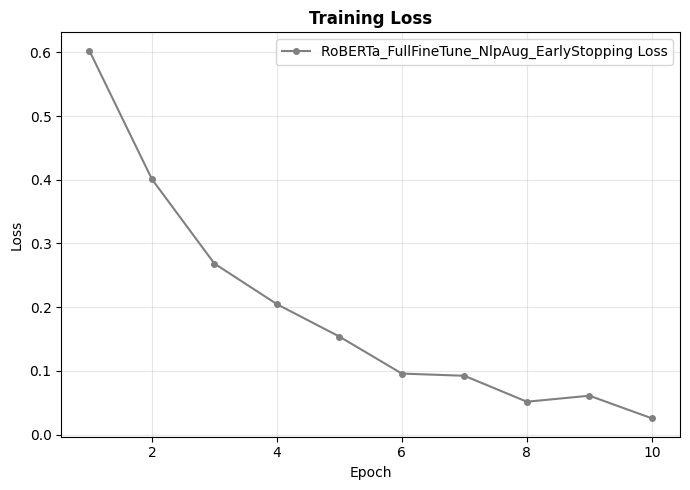

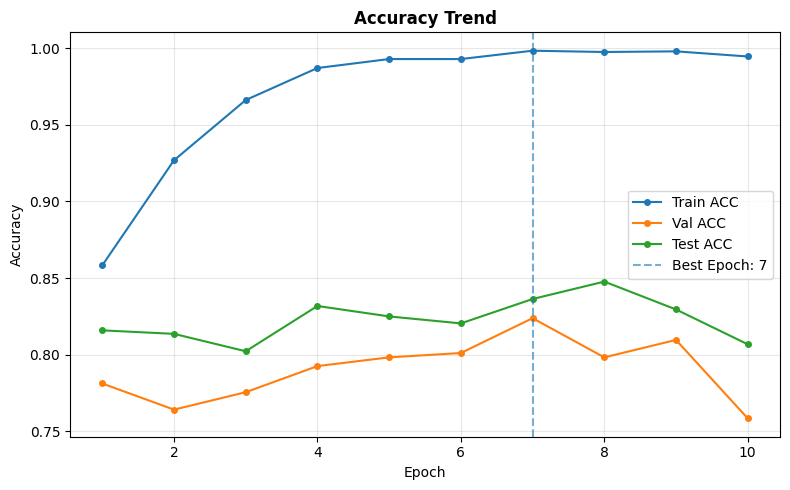

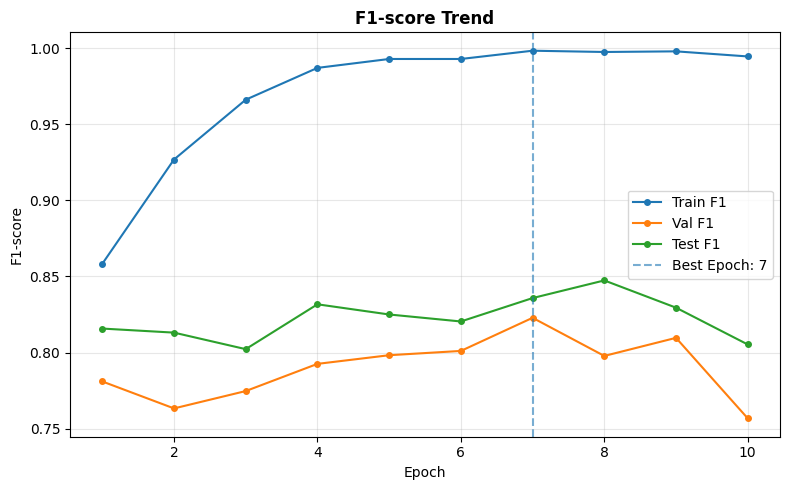


[Best Model 기준 최종 성능 비교]
RoBERTa_FullFineTune_NlpAug_EarlyStopping | Best Epoch: 7 | Best Val F1: 0.8228 | Final Test Accuracy: 0.8364 | Final Test Precision: 0.8395 | Final Test Recall: 0.8364 | Final Test F1: 0.8358

[Epoch별 과적합 Gap 확인, Train F1 - Val F1]

[RoBERTa_FullFineTune_NlpAug_EarlyStopping]
Epoch 01 | Train F1: 0.8583 | Val F1: 0.7810 | Test F1: 0.8158 | Gap: 0.0773
Epoch 02 | Train F1: 0.9268 | Val F1: 0.7633 | Test F1: 0.8131 | Gap: 0.1635
Epoch 03 | Train F1: 0.9661 | Val F1: 0.7747 | Test F1: 0.8022 | Gap: 0.1914
Epoch 04 | Train F1: 0.9870 | Val F1: 0.7926 | Test F1: 0.8317 | Gap: 0.1945
Epoch 05 | Train F1: 0.9929 | Val F1: 0.7983 | Test F1: 0.8250 | Gap: 0.1946
Epoch 06 | Train F1: 0.9929 | Val F1: 0.8011 | Test F1: 0.8204 | Gap: 0.1918
Epoch 07 | Train F1: 0.9983 | Val F1: 0.8228 | Test F1: 0.8358 | Gap: 0.1755
Epoch 08 | Train F1: 0.9975 | Val F1: 0.7978 | Test F1: 0.8474 | Gap: 0.1997
Epoch 09 | Train F1: 0.9979 | Val F1: 0.8097 | Test F1: 0.8295 | Gap: 0.1882
Epo

In [16]:
# ── 3) 시각화, Train / Val / Test 성능 비교 ──

colors = {
     "RoBERTa_256_PartialFreeze_NlpAug_EarlyStopping_Tuned": "tab:purple"
}


# -----------------------------
# 1. Training Loss 그래프
# -----------------------------
plt.figure(figsize=(7, 5))

for tag_name, res in all_results.items():
    c = colors.get(tag_name, "gray")
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(
        ep,
        res["loss"],
        color=c,
        marker="o",
        ms=4,
        label=f"{tag_name} Loss"
    )

plt.title("Training Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Accuracy 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_acc"], marker="o", ms=4, label="Train ACC")
    plt.plot(ep, res["val_acc"], marker="o", ms=4, label="Val ACC")
    plt.plot(ep, res["test_acc"], marker="o", ms=4, label="Test ACC")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("Accuracy Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. F1-score 그래프
# -----------------------------
plt.figure(figsize=(8, 5))

for tag_name, res in all_results.items():
    ep = range(1, len(res["loss"]) + 1)

    plt.plot(ep, res["train_f1"], marker="o", ms=4, label="Train F1")
    plt.plot(ep, res["val_f1"], marker="o", ms=4, label="Val F1")
    plt.plot(ep, res["test_f1"], marker="o", ms=4, label="Test F1")

    if res["best_epoch"] is not None:
        best_epoch = res["best_epoch"]

        plt.axvline(
            x=best_epoch,
            linestyle="--",
            alpha=0.6,
            label=f"Best Epoch: {best_epoch}"
        )

plt.title("F1-score Trend", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Best Model 기준 최종 성능 출력
# -----------------------------
print("\n[Best Model 기준 최종 성능 비교]")

for tag_name, res in all_results.items():
    print(
        f"{tag_name} | "
        f"Best Epoch: {res['best_epoch']} | "
        f"Best Val F1: {res['best_val_f1']:.4f} | "
        f"Final Test Accuracy: {res['best_test_acc']:.4f} | "
        f"Final Test Precision: {res['best_test_precision']:.4f} | "
        f"Final Test Recall: {res['best_test_recall']:.4f} | "
        f"Final Test F1: {res['best_test_f1']:.4f}"
    )


# -----------------------------
# 5. 과적합 Gap 확인
# -----------------------------
print("\n[Epoch별 과적합 Gap 확인, Train F1 - Val F1]")

for tag_name, res in all_results.items():
    print(f"\n[{tag_name}]")

    for i in range(len(res["train_f1"])):
        train_f1 = res["train_f1"][i]
        val_f1 = res["val_f1"][i]
        test_f1 = res["test_f1"][i]

        gap = train_f1 - val_f1

        print(
            f"Epoch {i+1:02d} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val F1: {val_f1:.4f} | "
            f"Test F1: {test_f1:.4f} | "
            f"Gap: {gap:.4f}"
        )